In [1]:
import os, csv, math, random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [2]:

# Experiment
SEED = 0
OUT_DIR = "PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/SOFT_GATE"
os.makedirs(OUT_DIR, exist_ok=True)

# Data
BATCH_SIZE = 128
NUM_WORKERS = 4
VAL_FRACTION = 0.1

# Train
EPOCHS = 200
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
LR_MILESTONES = [60, 120, 160]
LR_GAMMA = 0.2

# Loss (focal + sbece)
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = None          
SBECE_BINS = 15
SBECE_TEMP = 0.01          
BETA_SBECE = 1.0

# Pruning (gating)
LAMBDA_SPARSE = 1e-4        
SPARSITY_RAMP_EPOCHS = 20   
RECOVERY_EPOCHS = 40
PRUNE_RATIOS = [i/10 for i in range(0,10)] 
ACC_DROP_TOL = 0.01         # allow at most 1% absolute acc drop vs unpruned

# Metrics
ECE_BINS = 15
MEAN_SWEEP_BINS = list(range(5, 31))


In [3]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)


In [6]:
!pip install datasets

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 177.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 179.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 MB 223.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 202.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 202.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 240.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 210.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 234.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [38]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from datasets import load_dataset


class HFCIFAR10TorchDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.ds = hf_dataset
        self.transform = transform

        # Hugging Face CIFAR-10 usually uses "img"
        if "img" in self.ds.column_names:
            self.image_col = "img"
        elif "image" in self.ds.column_names:
            self.image_col = "image"
        else:
            raise ValueError(f"No image column found. Columns: {self.ds.column_names}")

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]

        img = item[self.image_col]   # PIL image
        label = item["label"]

        if self.transform is not None:
            img = self.transform(img)

        return img, label


def get_cifar10_loaders_hf(
    batch_size=128,
    val_fraction=0.1,
    num_workers=4,
    seed=0,
    cache_dir="./data/hf_cache"
):
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)

    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    # Download CIFAR-10 from Hugging Face
    ds = load_dataset(
        "uoft-cs/cifar10",
        cache_dir=cache_dir
    )

    # Split original train set into train/val
    split = ds["train"].train_test_split(
        test_size=val_fraction,
        seed=seed,
        shuffle=True
    )

    train_hf = split["train"]
    val_hf   = split["test"]
    test_hf  = ds["test"]

    train_set = HFCIFAR10TorchDataset(train_hf, transform=train_tf)

    # Recommended: no random augmentation for validation
    val_set = HFCIFAR10TorchDataset(val_hf, transform=test_tf)

    test_set = HFCIFAR10TorchDataset(test_hf, transform=test_tf)

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader

In [39]:
train_loader, val_loader, test_loader = get_cifar10_loaders_hf(
    batch_size=BATCH_SIZE,
    val_fraction=VAL_FRACTION,
    num_workers=NUM_WORKERS,
    seed=SEED,
    cache_dir="./data/hf_cache"
)

print(len(train_loader), len(val_loader), len(test_loader))

352 40 79


In [9]:


def get_cifar10_bn_loader_hf(
    batch_size=128,
    num_workers=4,
    cache_dir="./data/hf_cache"
):
    mean = (0.5071, 0.4867, 0.4408)
    std  = (0.2675, 0.2565, 0.2761)

    bn_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    ds = load_dataset(
        "uoft-cs/cifar10",
        cache_dir=cache_dir
    )

    train_noaug = HFCIFAR10TorchDataset(
        ds["train"],
        transform=bn_tf
    )

    bn_loader = DataLoader(
        train_noaug,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return bn_loader

In [10]:
bn_loader = get_cifar10_bn_loader_hf(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    cache_dir="./data/hf_cache"
)

In [11]:
class ChannelGate(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.gate = nn.Parameter(torch.ones(channels))

    def forward(self, x):
        return x * self.gate.view(1, -1, 1, 1)


class WideBasic(nn.Module):
    def __init__(self, in_planes, planes, dropout_rate, stride=1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, planes, 3, padding=1, bias=False)
        self.gate1 = ChannelGate(planes)

        self.dropout = nn.Dropout(p=dropout_rate) if dropout_rate > 0 else nn.Identity()

        self.bn2 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=stride, padding=1, bias=False)
        self.gate2 = ChannelGate(planes)

        self.shortcut = nn.Identity()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False)

    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.gate1(out)
        out = self.dropout(out)

        out = self.conv2(F.relu(self.bn2(out)))
        out = self.gate2(out)

        out += self.shortcut(x)
        return out


class WideResNet(nn.Module):
    def __init__(self, depth=28, widen_factor=10, dropout_rate=0.0, num_classes=100):
        super().__init__()
        assert (depth - 4) % 6 == 0, "WRN depth must be 6n+4"
        n = (depth - 4) // 6
        k = widen_factor

        stages = [16, 16*k, 32*k, 64*k]

        self.conv1 = nn.Conv2d(3, stages[0], 3, padding=1, bias=False)
        self.layer1 = self._make_layer(stages[0], stages[1], n, dropout_rate, stride=1)
        self.layer2 = self._make_layer(stages[1], stages[2], n, dropout_rate, stride=2)
        self.layer3 = self._make_layer(stages[2], stages[3], n, dropout_rate, stride=2)
        self.bn1 = nn.BatchNorm2d(stages[3])
        self.fc = nn.Linear(stages[3], num_classes)

        self._init_weights()

    def _make_layer(self, in_planes, planes, num_blocks, dropout_rate, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        curr_in = in_planes
        for s in strides:
            layers.append(WideBasic(curr_in, planes, dropout_rate, stride=s))
            curr_in = planes
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="linear")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.relu(self.bn1(out))
        out = F.adaptive_avg_pool2d(out, 1).view(out.size(0), -1)
        return self.fc(out)


def build_wrn28_10(num_classes=10, dropout=0.0):
    return WideResNet(depth=28, widen_factor=10, dropout_rate=dropout, num_classes=num_classes)


# sanity check
m = build_wrn28_10().to(DEVICE)
print(m(torch.randn(2, 3, 32, 32).to(DEVICE)).shape)  # [2, 100]


/opt/conda/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


torch.Size([2, 10])


## Gating module (for pruning) + “convert WRN to gated WRN”

### GatedConv2d

In [12]:
# =========================
# Channel-wise gating (BN-safe)
# =========================

class ChannelGate(nn.Module):
    """
    Channel-wise gate applied AFTER BN + ReLU.
    Safe for hardening + BN recalibration.
    """
    def __init__(self, channels):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(channels))

    def gate_values(self):
        return torch.sigmoid(self.logits)

    def forward(self, x):
        g = self.gate_values().view(1, -1, 1, 1)
        return x * g


# =========================
# Gate utilities
# =========================

@torch.no_grad()
def gather_all_gates(model: nn.Module) -> torch.Tensor:
    gates = []
    for m in model.modules():
        if isinstance(m, ChannelGate):
            gates.append(m.gate_values().detach().flatten())
    return torch.cat(gates) if len(gates) > 0 else torch.tensor([])


def gate_l1_sparsity_loss(model: nn.Module):
    """
    L1-style sparsity loss on gates.
    Use with: loss += LAMBDA_SPARSE * gate_l1_sparsity_loss(model)
    """
    vals = []
    for m in model.modules():
        if isinstance(m, ChannelGate):
            vals.append(m.gate_values())
    if len(vals) == 0:
        return torch.tensor(0.0, device=next(model.parameters()).device)
    return torch.cat(vals).mean()


# =========================
# Gate hardening (pruning)
# =========================

@torch.no_grad()
def harden_gates(model, prune_ratio):
    """
    prune_ratio: 0.1 -> prune 10%, keep 90%
    """
    for m in model.modules():
        if isinstance(m, ChannelGate):
            g = m.gate_values()
            k = int((1 - prune_ratio) * g.numel())

            if k <= 0:
                m.logits.fill_(-10.0)
                continue

            thresh = torch.topk(g, k, largest=True).values.min()
            m.logits.copy_(
                torch.where(
                    g >= thresh,
                    torch.tensor(10.0, device=g.device),
                    torch.tensor(-10.0, device=g.device),
                )
            )


## Losses: Focal + SB-ECE

### Focal loss

In [13]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)  # pt = softmax prob of true class
        loss = (1 - pt) ** self.gamma * ce

        if self.alpha is not None:
            # alpha can be scalar or per-class tensor
            if isinstance(self.alpha, (float, int)):
                loss = self.alpha * loss
            else:
                a = self.alpha.to(logits.device)
                loss = a[targets] * loss

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


### SB-ECE loss (binned, L2, soft memberships)

In [14]:
class SoftBinnedECELoss(nn.Module):
    """
    Soft-binning ECE (binned, L2).
    - anchors at (1/(2m), 3/(2m), ..., (2m-1)/(2m))
    - membership via softmax over - (p - anchor)^2 / temp
    - bin-weight = normalized sum of memberships
    - output = sqrt( sum_b w_b * (conf_b - acc_b)^2 )
    """
    def __init__(self, bins=15, temperature=0.01, eps=1e-5):
        super().__init__()
        self.bins = bins
        self.temperature = temperature
        self.eps = eps
        anchors = np.arange(1.0/(2*bins), 1.0, 1.0/bins)
        self.register_buffer("anchors", torch.tensor(anchors, dtype=torch.float32))

    def forward(self, logits, labels):
        probs = F.softmax(logits, dim=1)
        conf, pred = probs.max(dim=1)
        acc = pred.eq(labels).float()

        # [N, m]
        conf_tile = conf.unsqueeze(1)                         # [N,1]
        anchors = self.anchors.unsqueeze(0)                   # [1,m]
        scores = -((conf_tile - anchors) ** 2) / self.temperature
        c = F.softmax(scores, dim=1)                          # memberships

        # sum coeffs per bin: [m]
        sum_c = c.sum(dim=0)                                  # [m]
        sum_c_safe = torch.clamp(sum_c, min=self.eps)

        # soft bin confidence / accuracy: [m]
        conf_b = (c * conf_tile).sum(dim=0) / sum_c_safe
        acc_b  = (c * acc.unsqueeze(1)).sum(dim=0) / sum_c_safe

        # weights normalize to sum 1
        w = sum_c / torch.clamp(sum_c.sum(), min=self.eps)

        # L2 gap (paper uses L2 form)
        sb_ece = torch.sqrt(torch.sum(w * (conf_b - acc_b) ** 2) + self.eps)
        return sb_ece


## Metrics (Acc, NLL, ECE, TS-ECE, KS, mean-sweep CE)

In [15]:
@torch.no_grad()
def collect_logits_and_labels(model, loader, device):
    model.eval()
    logits_list, labels_list = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        logits_list.append(logits.detach().cpu())
        labels_list.append(y.detach().cpu())
    return torch.cat(logits_list, 0), torch.cat(labels_list, 0)

@torch.no_grad()
def acc_from_logits(logits, labels):
    return float((logits.argmax(1) == labels).float().mean().item())

@torch.no_grad()
def nll_from_logits(logits, labels):
    return float(F.cross_entropy(logits, labels, reduction="mean").item())

@torch.no_grad()
def ece_from_logits(logits, labels, n_bins=15, temperature=1.0):
    probs = F.softmax(logits / temperature, dim=1)
    conf, pred = probs.max(1)
    acc = pred.eq(labels).float()

    edges = torch.linspace(0, 1, n_bins + 1, device=logits.device)
    ece = torch.zeros(1, device=logits.device)

    for b in range(n_bins):
        lo, hi = edges[b], edges[b+1]
        inb = (conf > lo) & (conf <= hi)
        p = inb.float().mean()
        if p.item() > 0:
            ece += p * torch.abs(conf[inb].mean() - acc[inb].mean())
    return float(ece.item())

@torch.no_grad()
def ks_calibration_error(logits, labels, temperature=1.0):
    probs = F.softmax(logits / temperature, dim=1)
    conf, pred = probs.max(1)
    correct = pred.eq(labels).float()

    conf_sorted, idx = torch.sort(conf)
    corr_sorted = correct[idx]
    denom = torch.arange(1, len(conf_sorted)+1, device=logits.device).float()
    cum_acc = torch.cumsum(corr_sorted, 0) / denom
    cum_conf = torch.cumsum(conf_sorted, 0) / denom
    return float(torch.max(torch.abs(cum_acc - cum_conf)).item())

@torch.no_grad()
def mean_sweep_ce(logits, labels, bin_list, temperature=1.0):
    vals = [ece_from_logits(logits, labels, n_bins=b, temperature=temperature) for b in bin_list]
    return float(np.mean(vals))

def fit_temperature(logits_val_cpu, labels_val_cpu, device, max_iter=50):
    logits = logits_val_cpu.to(device)
    labels = labels_val_cpu.to(device)

    logT = torch.zeros(1, device=device, requires_grad=True)
    opt = torch.optim.LBFGS([logT], lr=0.5, max_iter=max_iter, line_search_fn="strong_wolfe")

    def closure():
        opt.zero_grad()
        T = torch.exp(logT)
        loss = F.cross_entropy(logits / T, labels)
        loss.backward()
        return loss

    opt.step(closure)
    T = float(torch.exp(logT).detach().cpu().item())
    return max(1e-3, min(T, 100.0))

@torch.no_grad()
def evaluate_all_metrics(model, val_loader, test_loader, device):
    logits_val, labels_val = collect_logits_and_labels(model, val_loader, device)
    logits_test, labels_test = collect_logits_and_labels(model, test_loader, device)

    logits_test = logits_test.to(device)
    labels_test = labels_test.to(device)

    # base
    acc = acc_from_logits(logits_test, labels_test)
    nll = nll_from_logits(logits_test, labels_test)
    ece = ece_from_logits(logits_test, labels_test, n_bins=ECE_BINS)
    ks  = ks_calibration_error(logits_test, labels_test)
    ms  = mean_sweep_ce(logits_test, labels_test, MEAN_SWEEP_BINS)

    # TS
    T = fit_temperature(logits_val, labels_val, device=device)
    ts_nll = nll_from_logits(logits_test / T, labels_test)
    ts_ece = ece_from_logits(logits_test, labels_test, n_bins=ECE_BINS, temperature=T)
    ts_ks  = ks_calibration_error(logits_test, labels_test, temperature=T)
    ts_ms  = mean_sweep_ce(logits_test, labels_test, MEAN_SWEEP_BINS, temperature=T)

    return {
        "acc": acc, "nll": nll, "ece": ece, "ts_ece": ts_ece,
        "ks": ks, "ts_ks": ts_ks,
        "mean_sweep_ce": ms, "ts_mean_sweep_ce": ts_ms,
        "ts_temperature": T,
        "ts_nll": ts_nll,
    }


## Train one epoch with (Focal + β·SB-ECE + λ·sparsity)

In [16]:
def train_one_epoch_focal_sbece(model, loader, optimizer, device,
                               focal_loss_fn, sbece_loss_fn,
                               beta_sbece=1.0, lambda_sparse=0.0):
    model.train()
    total = 0
    sum_total, sum_focal, sum_sbece, sum_sparse = 0.0, 0.0, 0.0, 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)

        focal = focal_loss_fn(logits, y)
        sbece = sbece_loss_fn(logits, y)
        sparse = gate_l1_sparsity_loss(model) if lambda_sparse > 0 else torch.tensor(0.0, device=device)

        loss = focal + beta_sbece * sbece + lambda_sparse * sparse
        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total += bs
        sum_total += float(loss.item()) * bs
        sum_focal += float(focal.item()) * bs
        sum_sbece += float(sbece.item()) * bs
        sum_sparse += float(sparse.item()) * bs

    return {
        "loss": sum_total / total,
        "focal": sum_focal / total,
        "sbece": sum_sbece / total,
        "sparse": sum_sparse / total,
    }


## Calibration-driven pruning: harden gates per layer + BN refresh + recovery

###  Hardening (per-layer top-k keep)

In [17]:
@torch.no_grad()
def harden_gates_per_layer(model: nn.Module,
                           keep_ratio: float,
                           prune_logit: float = -10.0):
    """
    Per-layer hardening:
    keep_ratio = fraction of channels kept PER gate layer
    Example: keep_ratio=0.9 keeps top 90% channels in each gate
    """
    eps = 1e-6

    for m in model.modules():
        if isinstance(m, ChannelGate):
            g = m.gate_values()          # [C]
            C = g.numel()

            k = max(1, int(round(keep_ratio * C)))
            thresh = torch.topk(g, k, largest=True).values.min()
            keep = g >= thresh

            # convert soft gates → hard logits
            g_clamped = g.clamp(eps, 1 - eps)
            logits_keep = torch.log(g_clamped / (1 - g_clamped))

            m.logits.data[keep] = logits_keep[keep]
            m.logits.data[~keep] = prune_logit



### BN refresh

In [18]:
@torch.no_grad()
def reset_bn_running_stats(model: nn.Module):
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.running_mean.zero_()
            m.running_var.fill_(1)

@torch.no_grad()
def update_bn_stats(model: nn.Module, loader, device, num_batches=100):
    model.train()
    n = 0
    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        _ = model(x)
        n += 1
        if n >= num_batches:
            break

### Recovery fine-tune (same loss but sparsity off)

In [19]:
def recovery_finetune(model, train_loader, device, lr, weight_decay,
                      focal_loss_fn, sbece_loss_fn, beta_sbece, epochs=40):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=MOMENTUM,
                                weight_decay=weight_decay, nesterov=True)
    for ep in range(1, epochs+1):
        tr = train_one_epoch_focal_sbece(
            model, train_loader, optimizer, device,
            focal_loss_fn, sbece_loss_fn,
            beta_sbece=beta_sbece, lambda_sparse=0.0
        )
        if ep % 5 == 0:
            print(f"   recovery epoch {ep:02d}/{epochs} done | loss={tr['loss']:.4f}")


## FULL RUN COMMAND: train (focal+sbece) + prune sweep + CSV

In [24]:
def run_focal_sbece_training_and_pruning_one_seed():
    # ---- loaders ----
    train_loader, val_loader, test_loader = get_cifar10_loaders_hf(
    batch_size=BATCH_SIZE,
    val_fraction=VAL_FRACTION,
    num_workers=NUM_WORKERS,
    seed=SEED,
    cache_dir="./data/hf_cache"
)
    # ---- model ----
    base_model = build_wrn28_10(num_classes=10, dropout=0.0).to(DEVICE)

    # ---- losses ----
    focal_fn = FocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA).to(DEVICE)
    sbece_fn = SoftBinnedECELoss(
        bins=SBECE_BINS,
        temperature=SBECE_TEMP
    ).to(DEVICE)

    # ---- optimizer / scheduler ----
    optimizer = torch.optim.SGD(
        base_model.parameters(),
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY,
        nesterov=True
    )
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=LR_MILESTONES,
        gamma=LR_GAMMA
    )

    print("\n==============================")
    print("TRAINING UNPRUNED BASELINE")
    print("==============================")

    # ---- TRAIN UNPRUNED ----
    for epoch in range(1, EPOCHS + 1):
        lambda_eff = LAMBDA_SPARSE * min(1.0, epoch / SPARSITY_RAMP_EPOCHS)

        tr = train_one_epoch_focal_sbece(
            base_model,
            train_loader,
            optimizer,
            DEVICE,
            focal_fn,
            sbece_fn,
            beta_sbece=BETA_SBECE,
            lambda_sparse=lambda_eff
        )
        scheduler.step()

        # ---- progress print ----
        if epoch % 2 == 0 or epoch == 1:
            base_model.eval()
            m = evaluate_all_metrics(
                base_model,
                val_loader,
                test_loader,
                DEVICE
            )

            g_all = gather_all_gates(base_model)
            gate_mean = float(g_all.mean().item()) if g_all.numel() else 0.0
            gate_density = float((g_all > 0.5).float().mean().item()) if g_all.numel() else 0.0

            # NEW: sparsity diagnostics
            sparse_val = gate_l1_sparsity_loss(base_model).item()
            lambda_eff = LAMBDA_SPARSE * min(1.0, epoch / SPARSITY_RAMP_EPOCHS)

            print(
                f"[BASE] Epoch {epoch:03d}/{EPOCHS} | "
                f"loss={tr['loss']:.4f} "
                f"(focal={tr['focal']:.4f}, sbece={tr['sbece']:.4f}, sparse={sparse_val:.4f}, λ={lambda_eff:.1e}) | "
                f"acc={m['acc']:.4f} ece={m['ece']:.4f} ks={m['ks']:.4f} | "
                f"gate_mean={gate_mean:.3f} density@0.5={gate_density:.3f}"
            )


    # ---- eval unpruned ----
    base_metrics = evaluate_all_metrics(
        base_model,
        val_loader,
        test_loader,
        DEVICE
    )
    print("\nUNPRUNED METRICS:", base_metrics)

    unpruned_path = os.path.join(
        OUT_DIR,
        "wrn28_10_cifar10_unpruned.pth"
    )
    torch.save(
        {"state_dict": base_model.state_dict(),
         "metrics": base_metrics},
        unpruned_path
    )
    print("Saved unpruned ->", unpruned_path)

    

In [25]:
csv_path = run_focal_sbece_training_and_pruning_one_seed()
print("CSV saved at:", csv_path)



TRAINING UNPRUNED BASELINE
[BASE] Epoch 001/200 | loss=1.4064 (focal=1.3218, sbece=0.0847, sparse=0.5001, λ=5.0e-06) | acc=0.4059 ece=0.0988 ks=0.2858 | gate_mean=0.500 density@0.5=0.529
[BASE] Epoch 004/200 | loss=0.6675 (focal=0.5895, sbece=0.0779, sparse=0.5004, λ=2.0e-05) | acc=0.5994 ece=0.0889 ks=0.8560 | gate_mean=0.500 density@0.5=0.672
[BASE] Epoch 006/200 | loss=0.5736 (focal=0.4951, sbece=0.0785, sparse=0.5005, λ=3.0e-05) | acc=0.5981 ece=0.0864 ks=0.1879 | gate_mean=0.501 density@0.5=0.699
[BASE] Epoch 010/200 | loss=0.4932 (focal=0.4178, sbece=0.0754, sparse=0.5009, λ=5.0e-05) | acc=0.6765 ece=0.0336 ks=0.1992 | gate_mean=0.501 density@0.5=0.876
[BASE] Epoch 012/200 | loss=0.4805 (focal=0.4055, sbece=0.0750, sparse=0.5010, λ=6.0e-05) | acc=0.6845 ece=0.0680 ks=0.1763 | gate_mean=0.501 density@0.5=0.928
[BASE] Epoch 014/200 | loss=0.4585 (focal=0.3819, sbece=0.0767, sparse=0.5011, λ=7.0e-05) | acc=0.7144 ece=0.0731 ks=0.2335 | gate_mean=0.501 density@0.5=0.932
[BASE] Epoch

In [26]:
# ============================================================
# HPO BETA CIFAR-10: Ours - beta sweep for calibration-aware FT
# Calibration-aware gates + focal + beta*SBECE recovery FT
# Hugging Face CIFAR-10 loader version
# ============================================================

import os, csv, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


# ============================================================
# Paths / HPO setup
# ============================================================

ABLATION_CKPT = (
    "PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/SOFT_GATE/"
    "wrn28_10_cifar10_unpruned.pth"
)

HPO_BETA_OUT_DIR = (
    "PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/"
    "HPO_beta"
)

os.makedirs(HPO_BETA_OUT_DIR, exist_ok=True)

print("Using unpruned checkpoint:", ABLATION_CKPT)
print("Saving HPO beta results to:", HPO_BETA_OUT_DIR)


# ============================================================
# Beta sweep setup
# ============================================================

# Full pruning sweep for beta HPO
BETA_SWEEP_PRUNE_RATIOS = [i / 10 for i in range(1, 10)]  # 0.1 ... 0.9

# Include beta=0.0 if you want focal-only recovery also in this same CSV.
# If focal-only is already done separately, remove 0.0.
BETA_GRID = [0.05, 0.1, 0.25, 0.5, 1.0, 2.0]


# ============================================================
# Focal classification loss
# Unique name to avoid overwriting your earlier FocalLoss
# ============================================================

class FocalLossHPO(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        loss = (1.0 - pt) ** self.gamma * ce

        if self.alpha is not None:
            if isinstance(self.alpha, (float, int)):
                loss = self.alpha * loss
            else:
                a = self.alpha.to(logits.device)
                loss = a[targets] * loss

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()

        return loss


# ============================================================
# Differentiable soft-binning ECE loss
# Unique name to avoid conflict with SoftBinnedECELoss
# ============================================================

class SoftBinningECELossHPO(nn.Module):
    """
    Soft-binning ECE-style calibration loss.

    Uses soft assignment of confidence values to bin centers.
    Prediction correctness is treated as a fixed target signal,
    while confidence remains differentiable through logits.
    """
    def __init__(self, n_bins=15, temp=0.01, eps=1e-8):
        super().__init__()
        self.n_bins = n_bins
        self.temp = temp
        self.eps = eps

        centers = torch.linspace(
            1.0 / (2 * n_bins),
            1.0 - 1.0 / (2 * n_bins),
            n_bins,
        )

        self.register_buffer("centers", centers)

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        confs, preds = probs.max(dim=1)
        correct = preds.eq(targets).float()

        # Soft assignment to confidence-bin centers
        dist = torch.abs(confs.unsqueeze(1) - self.centers.unsqueeze(0))
        weights = F.softmax(-dist / self.temp, dim=1)

        bin_mass = weights.sum(dim=0) + self.eps
        bin_prob = bin_mass / (weights.size(0) + self.eps)

        bin_conf = (weights * confs.unsqueeze(1)).sum(dim=0) / bin_mass
        bin_acc = (weights * correct.unsqueeze(1)).sum(dim=0) / bin_mass

        # Smooth absolute difference
        diff = torch.sqrt((bin_conf - bin_acc) ** 2 + self.eps)

        sbece = (bin_prob * diff).sum()
        return sbece


# ============================================================
# Gate utilities
# Requires: ChannelGate already defined in your notebook
# ============================================================

@torch.no_grad()
def harden_binary_gates_hpo(
    model: nn.Module,
    keep_ratio: float,
    on_logit: float = 10.0,
    off_logit: float = -10.0,
):
    """
    Per-layer hardening for ChannelGate.
    Keeps top keep_ratio channels per ChannelGate module.
    """
    for m in model.modules():
        if isinstance(m, ChannelGate):
            g = m.gate_values().detach()
            C = g.numel()

            k = max(1, int(round(keep_ratio * C)))

            idx = torch.topk(g, k, largest=True).indices
            keep = torch.zeros_like(g, dtype=torch.bool)
            keep[idx] = True

            m.logits.data[keep] = on_logit
            m.logits.data[~keep] = off_logit


def set_gate_trainable_hpo(model: nn.Module, trainable: bool):
    for m in model.modules():
        if isinstance(m, ChannelGate):
            m.logits.requires_grad_(trainable)


@torch.no_grad()
def gate_stats_hpo(model: nn.Module):
    gs = []

    for m in model.modules():
        if isinstance(m, ChannelGate):
            gs.append(m.gate_values().detach().flatten())

    if len(gs) == 0:
        return 0.0, 0.0

    g = torch.cat(gs, dim=0)

    gate_mean = float(g.mean().item())
    gate_density = float((g > 0.5).float().mean().item())

    return gate_mean, gate_density


# ============================================================
# Robust checkpoint loader
# ============================================================

def load_checkpoint_strict_hpo(model, ckpt_path, device):
    print(f"Loading checkpoint from: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location=device)

    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    elif isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
    elif isinstance(ckpt, dict) and "model" in ckpt:
        state_dict = ckpt["model"]
    else:
        state_dict = ckpt

    # remove DataParallel prefix if present
    state_dict = {
        k.replace("module.", "", 1) if k.startswith("module.") else k: v
        for k, v in state_dict.items()
    }

    missing, unexpected = model.load_state_dict(state_dict, strict=False)

    print("Checkpoint loaded.")
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))

    if len(missing) > 0:
        print("First missing keys:", missing[:10])

    if len(unexpected) > 0:
        print("First unexpected keys:", unexpected[:10])

    return model.to(device)


# ============================================================
# One epoch: focal + beta*SBECE fine-tuning
# ============================================================

def train_one_epoch_focal_sbece_hpo(
    model,
    loader,
    optimizer,
    device,
    focal_loss_fn,
    sbece_loss_fn,
    beta_sbece,
):
    model.train()

    total = 0
    sum_loss = 0.0
    sum_focal = 0.0
    sum_sbece = 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)

        focal = focal_loss_fn(logits, y)
        sbece = sbece_loss_fn(logits, y)

        loss = focal + beta_sbece * sbece

        loss.backward()
        optimizer.step()

        bs = y.size(0)

        total += bs
        sum_loss += float(loss.item()) * bs
        sum_focal += float(focal.item()) * bs
        sum_sbece += float(sbece.item()) * bs

    return {
        "loss": sum_loss / total,
        "focal": sum_focal / total,
        "sbece": sum_sbece / total,
        "beta_sbece": beta_sbece,
    }


# ============================================================
# Recovery fine-tuning: focal + beta*SBECE
# ============================================================

def recovery_finetune_focal_sbece_earlystop_cifar10(
    model,
    train_loader,
    val_loader,
    test_loader,
    device,
    lr,
    weight_decay,
    focal_loss_fn,
    sbece_loss_fn,
    beta_sbece,
    out_dir,
    tag,
    max_epochs=40,
    eval_every=1,
    patience=10,
    min_delta=1e-4,
    no_stop_before_ep=10,
    print_every=1,
):
    os.makedirs(out_dir, exist_ok=True)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=MOMENTUM,
        weight_decay=weight_decay,
        nesterov=True,
    )

    # For 40 recovery epochs, this gives LR drops at 20 and 30.
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[20, 30],
        gamma=0.1,
    )

    best_val_acc = -1.0
    best_state = None
    bad_steps = 0
    rows = []

    t0 = time.time()

    for ep in range(1, max_epochs + 1):
        tr = train_one_epoch_focal_sbece_hpo(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=device,
            focal_loss_fn=focal_loss_fn,
            sbece_loss_fn=sbece_loss_fn,
            beta_sbece=beta_sbece,
        )

        scheduler.step()

        row = {
            "epoch": ep,
            "lr": float(optimizer.param_groups[0]["lr"]),
            "train_loss": float(tr["loss"]),
            "train_focal": float(tr["focal"]),
            "train_sbece": float(tr["sbece"]),
            "beta_sbece": float(beta_sbece),
            "finetune_loss": "focal_plus_sbece",
        }

        do_eval = (ep % eval_every == 0) or (ep == 1) or (ep == max_epochs)

        if do_eval:
            model.eval()

            m = evaluate_all_metrics(
                model,
                val_loader,
                test_loader,
                device,
            )

            row.update({
                "val_acc": float(m["acc"]),
                "val_nll": float(m["nll"]),
                "val_ece": float(m["ece"]),
                "val_ts_ece": float(m["ts_ece"]),
                "val_ks": float(m.get("ks", float("nan"))),
                "val_mean_sweep_ce": float(m.get("mean_sweep_ce", float("nan"))),
            })

            improved = row["val_acc"] > (best_val_acc + min_delta)

            if improved:
                best_val_acc = row["val_acc"]
                best_state = {
                    k: v.detach().cpu()
                    for k, v in model.state_dict().items()
                }
                bad_steps = 0
            else:
                if ep >= no_stop_before_ep:
                    bad_steps += 1

            if (ep == 1) or (ep % print_every == 0) or improved:
                print(
                    f"   [{tag}] ep {ep:03d}/{max_epochs} | "
                    f"loss={row['train_loss']:.4f} "
                    f"focal={row['train_focal']:.4f} "
                    f"sbece={row['train_sbece']:.4f} "
                    f"beta={beta_sbece:.3f} | "
                    f"val_acc={row['val_acc']:.4f} "
                    f"val_ece={row['val_ece']:.4f} "
                    f"best_acc={best_val_acc:.4f} "
                    f"bad={bad_steps}/{patience}"
                )

            if (ep >= no_stop_before_ep) and (bad_steps >= patience):
                print(f"   [{tag}] Early stopping at epoch {ep}")
                break

        rows.append(row)

    # Restore best checkpoint according to validation accuracy
    if best_state is not None:
        model.load_state_dict(best_state, strict=True)

    model.eval()

    final_metrics = evaluate_all_metrics(
        model,
        val_loader,
        test_loader,
        device,
    )

    beta_tag = f"beta{str(beta_sbece).replace('.', 'p')}"

    curves_path = os.path.join(out_dir, f"curves_{tag}_{beta_tag}.csv")
    best_path = os.path.join(out_dir, f"best_{tag}_{beta_tag}.pth")

    pd.DataFrame(rows).to_csv(curves_path, index=False)

    torch.save(
        {
            "state_dict": model.state_dict(),
            "final_metrics": final_metrics,
            "tag": tag,
            "dataset": "cifar10",
            "ablation": "hpo_beta",
            "gate_selection": "calibration_aware",
            "finetune_loss": "focal_plus_sbece",
            "beta_sbece": float(beta_sbece),
        },
        best_path,
    )

    print(f"   [{tag}] Saved curves -> {curves_path}")
    print(f"   [{tag}] Saved best   -> {best_path}")
    print(f"   [{tag}] Time: {(time.time() - t0) / 60:.1f} min")

    return final_metrics, curves_path, best_path


# ============================================================
# Main CIFAR-10 beta HPO sweep
# ============================================================

def run_hpo_beta_from_checkpoint_cifar10(
    ckpt_path,
    out_dir,
    prune_ratios,
    beta_grid,
    max_recovery_epochs=40,
    eval_every=1,
    patience=10,
    no_stop_before_ep=10,
    bn_num_batches=100,
    cache_dir="./data/hf_cache",
):
    os.makedirs(out_dir, exist_ok=True)

    # --------------------------------------------------------
    # Load CIFAR-10 from Hugging Face
    # --------------------------------------------------------
    train_loader, val_loader, test_loader = get_cifar10_loaders_hf(
        batch_size=BATCH_SIZE,
        val_fraction=VAL_FRACTION,
        num_workers=NUM_WORKERS,
        seed=SEED,
        cache_dir=cache_dir,
    )

    bn_loader = get_cifar10_bn_loader_hf(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        cache_dir=cache_dir,
    )

    # --------------------------------------------------------
    # Load unpruned baseline
    # --------------------------------------------------------
    base_model = build_wrn28_10(num_classes=10, dropout=0.0).to(DEVICE)
    base_model = load_checkpoint_strict_hpo(base_model, ckpt_path, DEVICE)

    base_model.eval()

    base_metrics = evaluate_all_metrics(
        base_model,
        val_loader,
        test_loader,
        DEVICE,
    )

    gm, gd = gate_stats_hpo(base_model)

    print("\nBASELINE:")
    print(base_metrics)
    print(f"gate_mean={gm:.3f} density@0.5={gd:.3f}")

    base_state = {
        k: v.detach().cpu()
        for k, v in base_model.state_dict().items()
    }

    # --------------------------------------------------------
    # Losses
    # --------------------------------------------------------
    focal_fn = FocalLossHPO(
        gamma=FOCAL_GAMMA,
        alpha=FOCAL_ALPHA,
    ).to(DEVICE)

    sbece_fn = SoftBinningECELossHPO(
        n_bins=SBECE_BINS,
        temp=SBECE_TEMP,
    ).to(DEVICE)

    csv_path = os.path.join(out_dir, "metrics_hpo_beta_cifar10.csv")

    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)

        writer.writerow([
            "ablation",
            "dataset",
            "gate_selection",
            "finetune_loss",
            "beta_sbece",
            "prune_ratio",
            "keep_ratio",

            # baseline before pruning
            "base_acc",
            "base_nll",
            "base_ece",
            "base_ts_ece",
            "base_ks",
            "base_mean_sweep_ce",

            # after pruning/hardening + BN recalibration, before FT
            "post_harden_acc",
            "post_harden_nll",
            "post_harden_ece",
            "post_harden_ts_ece",
            "post_harden_ks",
            "post_harden_mean_sweep_ce",

            # after recovery FT
            "final_acc",
            "final_nll",
            "final_ece",
            "final_ts_ece",
            "final_ks",
            "final_mean_sweep_ce",

            "acc_drop_from_base",
            "accepted_acc_drop<=tol",
            "best_ckpt_path",
            "curves_csv_path",
        ])

        for beta_sbece in beta_grid:
            beta_tag = f"beta{str(beta_sbece).replace('.', 'p')}"
            beta_out_dir = os.path.join(out_dir, beta_tag)
            os.makedirs(beta_out_dir, exist_ok=True)

            print("\n" + "#" * 90)
            print(f"Running CIFAR-10 beta HPO: beta_sbece={beta_sbece}")
            print("Saving beta results to:", os.path.abspath(beta_out_dir))
            print("#" * 90)

            for prune_ratio in prune_ratios:
                keep_ratio = 1.0 - prune_ratio

                tag = (
                    f"cifar10_prune{int(prune_ratio * 100):02d}"
                    f"_keep{int(keep_ratio * 100):02d}"
                    f"_{beta_tag}"
                )

                print("\n" + "=" * 80)
                print(
                    f"[{tag}] Calibration-aware gates + "
                    f"focal + beta*SBECE recovery"
                )
                print("=" * 80)

                model_p = build_wrn28_10(num_classes=10, dropout=0.0).to(DEVICE)
                model_p.load_state_dict(base_state, strict=True)

                # -------------------------------
                # 1. Prune / harden gates
                # -------------------------------
                harden_binary_gates_hpo(
                    model_p,
                    keep_ratio=keep_ratio,
                )

                set_gate_trainable_hpo(
                    model_p,
                    trainable=False,
                )

                # -------------------------------
                # 2. BN recalibration after pruning
                # -------------------------------
                reset_bn_running_stats(model_p)

                update_bn_stats(
                    model_p,
                    bn_loader,
                    DEVICE,
                    num_batches=bn_num_batches,
                )

                # -------------------------------
                # 3. Evaluate after pruning/hardening,
                #    before recovery fine-tuning
                # -------------------------------
                model_p.eval()

                mh = evaluate_all_metrics(
                    model_p,
                    val_loader,
                    test_loader,
                    DEVICE,
                )

                print(
                    f"-> Post-harden/pre-FT eval: "
                    f"acc={mh['acc']:.4f}, "
                    f"nll={mh['nll']:.4f}, "
                    f"ece={mh['ece']:.4f}, "
                    f"ts_ece={mh['ts_ece']:.4f}, "
                    f"ks={mh.get('ks', float('nan')):.4f}, "
                    f"mean_sweep_ce={mh.get('mean_sweep_ce', float('nan')):.4f}"
                )

                # -------------------------------
                # 4. Recovery fine-tuning
                # -------------------------------
                m, curves_csv, best_ckpt = recovery_finetune_focal_sbece_earlystop_cifar10(
                    model=model_p,
                    train_loader=train_loader,
                    val_loader=val_loader,
                    test_loader=test_loader,
                    device=DEVICE,
                    lr=LR * 0.1,
                    weight_decay=WEIGHT_DECAY,
                    focal_loss_fn=focal_fn,
                    sbece_loss_fn=sbece_fn,
                    beta_sbece=beta_sbece,
                    out_dir=beta_out_dir,
                    tag=tag,
                    max_epochs=max_recovery_epochs,
                    eval_every=eval_every,
                    patience=patience,
                    no_stop_before_ep=no_stop_before_ep,
                    print_every=1,
                )

                acc_drop = float(base_metrics["acc"] - m["acc"])
                accepted = acc_drop <= ACC_DROP_TOL

                print(
                    f"-> Final: "
                    f"acc={m['acc']:.4f}, "
                    f"nll={m['nll']:.4f}, "
                    f"ece={m['ece']:.4f}, "
                    f"ts_ece={m['ts_ece']:.4f}, "
                    f"ks={m.get('ks', float('nan')):.4f}, "
                    f"mean_sweep_ce={m.get('mean_sweep_ce', float('nan')):.4f} | "
                    f"acc_drop={acc_drop:.4f} | accepted={accepted}"
                )

                writer.writerow([
                    "hpo_beta",
                    "cifar10",
                    "calibration_aware",
                    "focal_plus_sbece",
                    beta_sbece,
                    prune_ratio,
                    keep_ratio,

                    base_metrics["acc"],
                    base_metrics["nll"],
                    base_metrics["ece"],
                    base_metrics["ts_ece"],
                    base_metrics.get("ks", float("nan")),
                    base_metrics.get("mean_sweep_ce", float("nan")),

                    mh["acc"],
                    mh["nll"],
                    mh["ece"],
                    mh["ts_ece"],
                    mh.get("ks", float("nan")),
                    mh.get("mean_sweep_ce", float("nan")),

                    m["acc"],
                    m["nll"],
                    m["ece"],
                    m["ts_ece"],
                    m.get("ks", float("nan")),
                    m.get("mean_sweep_ce", float("nan")),

                    acc_drop,
                    accepted,
                    best_ckpt,
                    curves_csv,
                ])

                f.flush()

    print("\nDONE ->", csv_path)
    return csv_path

DEVICE: cuda
Using unpruned checkpoint: PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/SOFT_GATE/wrn28_10_cifar10_unpruned.pth
Saving HPO beta results to: PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta


In [ ]:
hpo_beta_csv = run_hpo_beta_from_checkpoint_cifar10(
    ckpt_path=ABLATION_CKPT,
    out_dir=HPO_BETA_OUT_DIR,
    prune_ratios=BETA_SWEEP_PRUNE_RATIOS,
    beta_grid=BETA_GRID,
    max_recovery_epochs=RECOVERY_EPOCHS,
    eval_every=1,
    patience=10,
    no_stop_before_ep=10,
    bn_num_batches=100,
    cache_dir="./data/hf_cache",
)

print("HPO beta CSV:", hpo_beta_csv)

Loading checkpoint from: PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/SOFT_GATE/wrn28_10_cifar10_unpruned.pth
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0

BASELINE:
{'acc': 0.9389999508857727, 'nll': 0.18786916136741638, 'ece': 0.019031286239624023, 'ts_ece': 0.0067284321412444115, 'ks': 0.2581251859664917, 'ts_ks': 0.24888628721237183, 'mean_sweep_ce': 0.019382272775356587, 'ts_mean_sweep_ce': 0.006131754910501723, 'ts_temperature': 1.297042965888977, 'ts_nll': 0.17953453958034515}
gate_mean=0.501 density@0.5=0.785

##########################################################################################
Running CIFAR-10 beta HPO: beta_sbece=0.05
Saving beta results to: /home/jovyan/GATEDECORATOR/CIFAR-10/PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta/beta0p05
##########################################################################################

[cifar10_prune10_keep90_beta0p05] Calibration-aware gates + focal + beta*SBECE recovery
-> Post-harden/pre-FT eval: acc=0.

In [33]:
import os
import pandas as pd
import numpy as np

# ============================================================
# Paths: CIFAR-10
# ============================================================

BASE_DIR = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE"
)

HPO_CSV = os.path.join(
    BASE_DIR,
    "HPO_beta/metrics_hpo_beta_cifar10.csv"
)

BETA0_CSV = os.path.join(
    BASE_DIR,
    "metrics_ours_minus_calib_ft.csv"
)

OUT_DIR = os.path.join(BASE_DIR, "HPO_beta_selection")
os.makedirs(OUT_DIR, exist_ok=True)

CLEAN_CSV = os.path.join(OUT_DIR, "clean_hpo_beta_metrics_cifar10.csv")
SELECTED_CSV = os.path.join(OUT_DIR, "selected_beta_per_pruning_ratio_cifar10.csv")


# ============================================================
# Explicit HPO grid
# beta=0 comes from focal-only FT
# ============================================================

BETA_GRID = [0.05, 0.10, 0.25, 0.50]
OFFICIAL_BETA_GRID = [0.0] + BETA_GRID

OFFICIAL_PRUNE_RATIOS = [i / 10 for i in range(1, 10)]  # 0.1 ... 0.9


# ============================================================
# Helper: robust float filtering
# ============================================================

def keep_official_values(df, beta_grid, prune_ratios):
    df = df.copy()

    df["beta_key"] = df["beta"].round(4)
    df["prune_key"] = df["prune_ratio"].round(4)

    beta_keys = [round(b, 4) for b in beta_grid]
    prune_keys = [round(p, 4) for p in prune_ratios]

    df = df[
        df["beta_key"].isin(beta_keys)
        & df["prune_key"].isin(prune_keys)
    ].copy()

    df = df.drop(columns=["beta_key", "prune_key"])

    return df


def extract_acc_ece(df):
    """
    Handles both possible CSV formats:
    1. final_acc / final_ece
    2. acc / ece
    """

    if {"final_acc", "final_ece"}.issubset(df.columns):
        out = df[[
            "prune_ratio",
            "final_acc",
            "final_ece",
        ]].copy()

        out = out.rename(columns={
            "final_acc": "acc",
            "final_ece": "ece",
        })

        return out

    elif {"acc", "ece"}.issubset(df.columns):
        out = df[[
            "prune_ratio",
            "acc",
            "ece",
        ]].copy()

        return out

    else:
        raise KeyError(
            "Could not find required columns. Need either "
            "['final_acc', 'final_ece'] or ['acc', 'ece'].\n"
            f"Available columns: {df.columns.tolist()}"
        )


# ============================================================
# 1. Load beta sweep results: beta > 0
# ============================================================

df_hpo = pd.read_csv(HPO_CSV)

hpo_clean = extract_acc_ece(df_hpo)

# add beta column from beta_sbece
hpo_clean["beta"] = df_hpo["beta_sbece"].values
hpo_clean["source"] = "beta_sweep"

# keep only official non-zero beta values
hpo_clean = keep_official_values(
    hpo_clean,
    beta_grid=BETA_GRID,
    prune_ratios=OFFICIAL_PRUNE_RATIOS,
)


# ============================================================
# 2. Load focal-only result and add as beta = 0
# ============================================================

df_beta0 = pd.read_csv(BETA0_CSV)

beta0_clean = extract_acc_ece(df_beta0)

beta0_clean["beta"] = 0.0
beta0_clean["source"] = "focal_only"

beta0_clean = keep_official_values(
    beta0_clean,
    beta_grid=[0.0],
    prune_ratios=OFFICIAL_PRUNE_RATIOS,
)


# ============================================================
# 3. Combine and clean
# ============================================================

clean_df = pd.concat([beta0_clean, hpo_clean], ignore_index=True)

clean_df = clean_df[[
    "prune_ratio",
    "beta",
    "acc",
    "ece",
    "source",
]]

# Remove accidental duplicates, keeping the last recorded result
clean_df = clean_df.sort_values(["prune_ratio", "beta"]).drop_duplicates(
    subset=["prune_ratio", "beta"],
    keep="last"
)

clean_df = clean_df.sort_values(["prune_ratio", "beta"]).reset_index(drop=True)

clean_df.to_csv(CLEAN_CSV, index=False)

print("Saved clean HPO CSV:", CLEAN_CSV)
display(clean_df)


# ============================================================
# 4. Check missing beta/pruning combinations
# ============================================================

expected = pd.MultiIndex.from_product(
    [OFFICIAL_PRUNE_RATIOS, OFFICIAL_BETA_GRID],
    names=["prune_ratio", "beta"]
).to_frame(index=False)

expected["prune_ratio"] = expected["prune_ratio"].round(4)
expected["beta"] = expected["beta"].round(4)

available = clean_df[["prune_ratio", "beta"]].copy()
available["prune_ratio"] = available["prune_ratio"].round(4)
available["beta"] = available["beta"].round(4)

missing = expected.merge(
    available,
    on=["prune_ratio", "beta"],
    how="left",
    indicator=True
)

missing = missing[missing["_merge"] == "left_only"].drop(columns=["_merge"])

if len(missing) > 0:
    print("\nWARNING: Missing official HPO combinations:")
    display(missing)
else:
    print("\nAll official HPO combinations are available.")

Saved clean HPO CSV: PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta_selection/clean_hpo_beta_metrics_cifar10.csv


,prune_ratio,beta,acc,ece,source
0,0.1,0.00,0.9489,0.027487,focal_only
1,0.1,0.05,0.9483,0.009627,beta_sweep
2,0.1,0.10,0.9428,0.004981,beta_sweep
3,0.1,0.25,0.9471,0.005945,beta_sweep
4,0.1,0.50,0.9337,0.009309,beta_sweep
5,0.2,0.00,0.9462,0.022139,focal_only
6,0.2,0.05,0.9474,0.007952,beta_sweep
7,0.2,0.10,0.9414,0.003445,beta_sweep
8,0.2,0.25,0.9444,0.006036,beta_sweep
9,0.2,0.50,0.9343,0.009905,beta_sweep



All official HPO combinations are available.


In [34]:
# ============================================================
# 4. Select best beta per pruning ratio
# Rule:
# - For each pruning ratio, find max validation accuracy.
# - Keep betas within 0.5 percentage point of that max accuracy.
# - Among them, choose lowest ECE.
# ============================================================

df = pd.read_csv(CLEAN_CSV)

ACC_TOL = 0.005   # 0.5 percentage point because acc is in 0-1 scale

df["max_acc_at_prune"] = df.groupby("prune_ratio")["acc"].transform("max")
df["acc_gap_from_best"] = df["max_acc_at_prune"] - df["acc"]

df["accuracy_feasible"] = df["acc_gap_from_best"] <= ACC_TOL

feasible_df = df[df["accuracy_feasible"]].copy()

selected = (
    feasible_df
    .sort_values(
        ["prune_ratio", "ece", "acc", "beta"],
        ascending=[True, True, False, True]
    )
    .groupby("prune_ratio")
    .head(1)
    .reset_index(drop=True)
)

selected.to_csv(SELECTED_CSV, index=False)

print("Saved selected beta CSV:", SELECTED_CSV)
display(selected)

Saved selected beta CSV: PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta_selection/selected_beta_per_pruning_ratio_cifar10.csv


,prune_ratio,beta,acc,ece,source,max_acc_at_prune,acc_gap_from_best,accuracy_feasible
0,0.1,0.25,0.9471,0.005945,beta_sweep,0.9489,0.0018,True
1,0.2,0.25,0.9444,0.006036,beta_sweep,0.9474,0.0030,True
2,0.3,0.25,0.9446,0.004803,beta_sweep,0.9473,0.0027,True
3,0.4,0.10,0.9454,0.006469,beta_sweep,0.9479,0.0025,True
4,0.5,0.10,0.9473,0.006468,beta_sweep,0.9473,0.0000,True
5,0.6,0.10,0.9459,0.007858,beta_sweep,0.9459,0.0000,True
6,0.7,0.10,0.9437,0.006046,beta_sweep,0.9441,0.0004,True
7,0.8,0.10,0.9417,0.010725,beta_sweep,0.9425,0.0008,True
8,0.9,0.05,0.9222,0.028727,beta_sweep,0.9222,0.0000,True


In [49]:
import os
import glob
import numpy as np

def beta_to_tag(beta):
    return f"beta{str(float(beta)).replace('.', 'p')}"


def resolve_selected_ckpt_path_cifar10(row, hpo_beta_dir):
    """
    Robust checkpoint resolver for CIFAR-10 selected-beta evaluation.

    Handles:
    - beta = 0 / focal-only checkpoints
    - beta > 0 / HPO beta-sweep checkpoints
    - keep19 vs keep20 naming issue from floating-point truncation
    - possible duplicated beta tag in filename
    """

    prune_ratio = float(row["prune_ratio"])
    beta = float(row["beta"])
    source = row["source"]

    prune_pct = int(round(prune_ratio * 100))

    # --------------------------------------------------
    # Case 1: focal-only / beta = 0
    # --------------------------------------------------
    if source == "focal_only" or np.isclose(beta, 0.0):

        patterns = [
            os.path.join(
                focal_only_dir,
                f"best_cifar10_prune{prune_pct:02d}_keep*_cls_only.pth"
            ),
            os.path.join(
                focal_only_dir,
                f"best_*prune{prune_pct:02d}_keep*_cls_only.pth"
            ),
            os.path.join(
                focal_only_dir,
                f"*prune{prune_pct:02d}_keep*_cls_only.pth"
            ),
        ]

        matches = []
        for pattern in patterns:
            matches.extend(glob.glob(pattern))

        matches = sorted(set(matches))

        if len(matches) == 0:
            raise FileNotFoundError(
                "Missing CIFAR-10 focal-only checkpoint. Tried patterns:\n"
                + "\n".join(patterns)
            )

        if len(matches) > 1:
            print("[WARN] Multiple CIFAR-10 focal-only matches found. Using first:")
            for m in matches:
                print("   ", m)

        return matches[0]

    # --------------------------------------------------
    # Case 2: beta-sweep checkpoint
    # --------------------------------------------------
    beta_tag = beta_to_tag(beta)
    beta_dir = os.path.join(hpo_beta_dir, beta_tag)

    patterns = [
        # if checkpoints are inside beta0p05/beta0p10/... folders
        os.path.join(
            beta_dir,
            f"best_cifar10_prune{prune_pct:02d}_keep*_{beta_tag}_{beta_tag}.pth"
        ),
        os.path.join(
            beta_dir,
            f"best_cifar10_prune{prune_pct:02d}_keep*_{beta_tag}.pth"
        ),
        os.path.join(
            beta_dir,
            f"best_*prune{prune_pct:02d}_keep*_{beta_tag}*.pth"
        ),

        # fallback: if checkpoints are directly inside hpo_beta_dir
        os.path.join(
            hpo_beta_dir,
            f"best_cifar10_prune{prune_pct:02d}_keep*_{beta_tag}_{beta_tag}.pth"
        ),
        os.path.join(
            hpo_beta_dir,
            f"best_cifar10_prune{prune_pct:02d}_keep*_{beta_tag}.pth"
        ),
        os.path.join(
            hpo_beta_dir,
            f"best_*prune{prune_pct:02d}_keep*_{beta_tag}*.pth"
        ),
    ]

    matches = []
    for pattern in patterns:
        matches.extend(glob.glob(pattern))

    matches = sorted(set(matches))

    if len(matches) == 0:
        raise FileNotFoundError(
            "Missing CIFAR-10 beta-sweep checkpoint. Tried patterns:\n"
            + "\n".join(patterns)
        )

    if len(matches) > 1:
        print("[WARN] Multiple CIFAR-10 beta-sweep matches found. Using first:")
        for m in matches:
            print("   ", m)

    return matches[0]

In [50]:
# --------------------------------------------------
# Bootstrap utility (FULL CIFAR metric set)
# --------------------------------------------------

def bootstrap_metrics_from_logits(
    logits_val_cpu,
    labels_val_cpu,
    logits_test_cpu,
    labels_test_cpu,
    device,
    n_boot=300,
):
    """
    Bootstrap uncertainty for:
    acc, nll, ece, ks, mean_sweep_ce,
    ts_ece, ts_nll, ts_ks, ts_mean_sweep_ce
    """

    N = logits_test_cpu.shape[0]

    results = []

    for _ in range(n_boot):

        # ---- Resample TEST set ----
        idx = torch.randint(0, N, (N,))
        logits_test_b = logits_test_cpu[idx].to(device)
        labels_test_b = labels_test_cpu[idx].to(device)

        # ---- Base metrics ----
        acc = acc_from_logits(logits_test_b, labels_test_b)
        nll = nll_from_logits(logits_test_b, labels_test_b)
        ece = ece_from_logits(logits_test_b, labels_test_b, n_bins=ECE_BINS)
        ks  = ks_calibration_error(logits_test_b, labels_test_b)
        ms  = mean_sweep_ce(logits_test_b, labels_test_b, MEAN_SWEEP_BINS)

        # ---- Temperature Scaling (fit on VAL each time) ----
        T = fit_temperature(
            logits_val_cpu,
            labels_val_cpu,
            device=device
        )

        ts_nll = nll_from_logits(logits_test_b / T, labels_test_b)
        ts_ece = ece_from_logits(logits_test_b, labels_test_b, n_bins=ECE_BINS, temperature=T)
        ts_ks  = ks_calibration_error(logits_test_b, labels_test_b, temperature=T)
        ts_ms  = mean_sweep_ce(logits_test_b, labels_test_b, MEAN_SWEEP_BINS, temperature=T)

        results.append({
            "acc": acc,
            "nll": nll,
            "ece": ece,
            "ks": ks,
            "mean_sweep_ce": ms,
            "ts_ece": ts_ece,
            "ts_nll": ts_nll,
            "ts_ks": ts_ks,
            "ts_mean_sweep_ce": ts_ms,
        })

    df_boot = pd.DataFrame(results)

    std_dict = {k + "_std": float(df_boot[k].std()) for k in df_boot.columns}

    return std_dict


In [52]:
@torch.no_grad()
def evaluate_checkpoint_with_bootstrap_cifar10(
    ckpt_path: str,
    val_loader,
    test_loader,
    device,
    n_boot=300,
):
    # -----------------------
    # Load model
    # -----------------------
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt

    model = build_wrn28_10(num_classes=10, dropout=0.0).to(device)
    model.load_state_dict(state_dict, strict=True)
    model.eval()

    # -----------------------
    # Collect logits once
    # -----------------------
    logits_val, labels_val = collect_logits_and_labels(model, val_loader, device)
    logits_test, labels_test = collect_logits_and_labels(model, test_loader, device)

    logits_val_cpu = logits_val.detach().cpu()
    labels_val_cpu = labels_val.detach().cpu()
    logits_test_cpu = logits_test.detach().cpu()
    labels_test_cpu = labels_test.detach().cpu()

    # -----------------------
    # Compute mean metrics on test set
    # -----------------------
    metrics = evaluate_all_metrics(model, val_loader, test_loader, device)

    # -----------------------
    # Bootstrap std on test set
    # -----------------------
    boot = bootstrap_metrics_from_logits(
        logits_val_cpu,
        labels_val_cpu,
        logits_test_cpu,
        labels_test_cpu,
        device,
        n_boot=n_boot,
    )

    return {**metrics, **boot}

In [53]:
def evaluate_baseline_and_selected_beta_models_cifar10(
    baseline_ckpt: str,
    selected_beta_csv: str,
    hpo_beta_dir: str,
    device,
    n_boot=300,
    out_csv=None,
):
    """
    Final CIFAR-10 evaluation after beta selection.

    1. Reads selected_beta_per_pruning_ratio_cifar10.csv
    2. Loads the selected checkpoint for each pruning ratio
    3. Evaluates on test set
    4. Bootstraps test metrics to get std
    """

    train_loader, val_loader, test_loader = get_cifar10_loaders_hf(
        batch_size=BATCH_SIZE,
        val_fraction=VAL_FRACTION,
        num_workers=NUM_WORKERS,
        seed=SEED,
        cache_dir="./data/hf_cache",
    )

    selected_df = pd.read_csv(selected_beta_csv)
    selected_df = selected_df.sort_values("prune_ratio").reset_index(drop=True)

    rows = []

    # ------------------ BASELINE ------------------
    print("\nEvaluating CIFAR-10 BASELINE")

    base_metrics = evaluate_checkpoint_with_bootstrap_cifar10(
        baseline_ckpt,
        val_loader,
        test_loader,
        device,
        n_boot=n_boot,
    )

    rows.append({
        "model": "baseline",
        "prune_ratio": 0.0,
        "keep_ratio": 1.0,
        "selected_beta": np.nan,
        "selection_source": "baseline",
        "selected_val_acc": np.nan,
        "selected_val_ece": np.nan,
        "acc_gap_from_best": np.nan,
        "ckpt_path": baseline_ckpt,
        **base_metrics,
    })

    # ------------------ SELECTED PRUNED MODELS ------------------
    for _, row in selected_df.iterrows():

        prune_ratio = float(row["prune_ratio"])
        keep_ratio = 1.0 - prune_ratio
        beta = float(row["beta"])
        source = row["source"]

        tag = (
            f"prune{int(round(prune_ratio * 100)):02d}"
            f"_keep{int(round(keep_ratio * 100)):02d}"
        )

        ckpt_path = resolve_selected_ckpt_path_cifar10(
            row=row,
            hpo_beta_dir=hpo_beta_dir,
        )

        print("\n" + "=" * 80)
        print(f"Evaluating selected CIFAR-10 model: {tag}")
        print(f"Selected beta: {beta:.2f} | source: {source}")
        print(f"Checkpoint: {ckpt_path}")
        print("=" * 80)

        m = evaluate_checkpoint_with_bootstrap_cifar10(
            ckpt_path,
            val_loader,
            test_loader,
            device,
            n_boot=n_boot,
        )

        rows.append({
            "model": tag,
            "prune_ratio": prune_ratio,
            "keep_ratio": keep_ratio,
            "selected_beta": beta,
            "selection_source": source,

            # metrics used during beta selection
            "selected_val_acc": row.get("acc", np.nan),
            "selected_val_ece": row.get("ece", np.nan),
            "acc_gap_from_best": row.get("acc_gap_from_best", np.nan),

            "ckpt_path": ckpt_path,
            **m,
        })

    df = pd.DataFrame(rows)

    if out_csv is not None:
        df.to_csv(out_csv, index=False)
        print("\nSaved final CIFAR-10 bootstrap results to:", out_csv)

    return df


In [54]:
BASELINE_CKPT = (
    "PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/SOFT_GATE/"
    "wrn28_10_cifar10_unpruned.pth"
)

SELECTED_BETA_CSV = (
    "PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/"
    "HPO_beta_selection/selected_beta_per_pruning_ratio_cifar10.csv"
)

HPO_BETA_DIR = (
    "PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta"
)



OUT_CSV = (
    "PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/"
    "HPO_beta_selection/final_selected_beta_test_bootstrap_cifar10.csv"
)

df_final_cifar10 = evaluate_baseline_and_selected_beta_models_cifar10(
    baseline_ckpt=BASELINE_CKPT,
    selected_beta_csv=SELECTED_BETA_CSV,
    hpo_beta_dir=HPO_BETA_DIR,
    device=DEVICE,
    n_boot=300,
    out_csv=OUT_CSV,
)

df_final_cifar10


Evaluating CIFAR-10 BASELINE

Evaluating selected CIFAR-10 model: prune10_keep90
Selected beta: 0.25 | source: beta_sweep
Checkpoint: PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta/beta0p25/best_cifar10_prune10_keep90_beta0p25_beta0p25.pth

Evaluating selected CIFAR-10 model: prune20_keep80
Selected beta: 0.25 | source: beta_sweep
Checkpoint: PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta/beta0p25/best_cifar10_prune20_keep80_beta0p25_beta0p25.pth

Evaluating selected CIFAR-10 model: prune30_keep70
Selected beta: 0.25 | source: beta_sweep
Checkpoint: PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta/beta0p25/best_cifar10_prune30_keep70_beta0p25_beta0p25.pth

Evaluating selected CIFAR-10 model: prune40_keep60
Selected beta: 0.10 | source: beta_sweep
Checkpoint: PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta/beta0p1/best_cifar10_prune40_keep60_beta0p1_beta0p1.pth

Evaluating selected CIFAR-10 model: prune50_keep50
Selected beta: 0.10 | source: beta_sweep
Checkpoint: PRUN

,model,prune_ratio,keep_ratio,selected_beta,selection_source,selected_val_acc,selected_val_ece,acc_gap_from_best,ckpt_path,acc,...,ts_nll,acc_std,nll_std,ece_std,ks_std,mean_sweep_ce_std,ts_ece_std,ts_nll_std,ts_ks_std,ts_mean_sweep_ce_std
0,baseline,0.0,1.0,NaN,baseline,NaN,NaN,NaN,PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/SOF...,0.9390,...,0.179535,0.002362,0.007236,0.001969,0.180169,0.001907,0.001609,0.005848,0.143460,0.001199
1,prune10_keep90,0.1,0.9,0.25,beta_sweep,0.9471,0.005945,0.0018,PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO...,0.9471,...,0.160871,0.002148,0.005368,0.001522,0.199613,0.000962,0.001531,0.005376,0.199453,0.000953
2,prune20_keep80,0.2,0.8,0.25,beta_sweep,0.9444,0.006036,0.0030,PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO...,0.9444,...,0.162266,0.002413,0.006025,0.001483,0.052999,0.001273,0.001562,0.006132,0.051808,0.001251
3,prune30_keep70,0.3,0.7,0.25,beta_sweep,0.9446,0.004803,0.0027,PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO...,0.9446,...,0.168039,0.002208,0.005722,0.001382,0.221909,0.001020,0.001308,0.005742,0.221560,0.000999
4,prune40_keep60,0.4,0.6,0.10,beta_sweep,0.9454,0.006469,0.0025,PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO...,0.9454,...,0.164992,0.002363,0.005994,0.001642,0.131464,0.001198,0.001524,0.006088,0.201085,0.001172
5,prune50_keep50,0.5,0.5,0.10,beta_sweep,0.9473,0.006468,0.0000,PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO...,0.9473,...,0.162727,0.002248,0.005983,0.001490,0.198311,0.001213,0.001594,0.006147,0.194462,0.001146
6,prune60_keep40,0.6,0.4,0.10,beta_sweep,0.9459,0.007858,0.0000,PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO...,0.9459,...,0.164463,0.002363,0.006173,0.001413,0.004945,0.001152,0.001506,0.006327,0.005447,0.001099
7,prune70_keep30,0.7,0.3,0.10,beta_sweep,0.9437,0.006046,0.0004,PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO...,0.9437,...,0.170086,0.002236,0.005950,0.001477,0.176975,0.001176,0.001477,0.006160,0.172720,0.001062
8,prune80_keep20,0.8,0.2,0.10,beta_sweep,0.9417,0.010725,0.0008,PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO...,0.9417,...,0.181454,0.002279,0.005825,0.001592,0.009122,0.001440,0.001513,0.006189,0.008608,0.001131
9,prune90_keep10,0.9,0.1,0.05,beta_sweep,0.9222,0.028727,0.0000,PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO...,0.9222,...,0.237660,0.002682,0.006157,0.002277,0.062083,0.002178,0.001829,0.006967,0.102178,0.001513


In [55]:
# --------------------------------------------------
# FINAL CIFAR-10 SELECTED-BETA TEST METRICS TABLE
# mean ± std
# --------------------------------------------------

df_raw = df_final_cifar10.copy()

def mean_std_str(mean, std, scale=1.0):
    return f"{mean * scale:.2f} ± {std * scale:.2f}"

# Pruning (%)
df_raw["prune (%)"] = (df_raw["prune_ratio"] * 100).round(0).astype(int)

# Selected beta
df_raw["beta"] = df_raw["selected_beta"].apply(
    lambda x: "--" if pd.isna(x) else f"{x:.2f}"
)

# Accuracy (%)
df_raw["acc (%)"] = df_raw.apply(
    lambda r: mean_std_str(r["acc"], r["acc_std"], scale=100),
    axis=1
)

# NLL
df_raw["nll"] = df_raw.apply(
    lambda r: mean_std_str(r["nll"], r["nll_std"], scale=1),
    axis=1
)

# ECE (%)
df_raw["ece (%)"] = df_raw.apply(
    lambda r: mean_std_str(r["ece"], r["ece_std"], scale=100),
    axis=1
)

# KS (%)
df_raw["ks (%)"] = df_raw.apply(
    lambda r: mean_std_str(r["ks"], r["ks_std"], scale=100),
    axis=1
)

# Mean Sweep CE (%)
df_raw["mean_sweep_ce (%)"] = df_raw.apply(
    lambda r: mean_std_str(r["mean_sweep_ce"], r["mean_sweep_ce_std"], scale=100),
    axis=1
)

# Final columns for paper
df_raw = df_raw[[
    "prune (%)",
    "beta",
    "acc (%)",
    "nll",
    "ece (%)",
    "ks (%)",
    "mean_sweep_ce (%)"
]]

OUT_RAW_CSV = (
    "PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/"
    "HPO_beta_selection/cifar10_selected_beta_raw_metrics_paper.csv"
)

df_raw.to_csv(OUT_RAW_CSV, index=False)

print("Saved ->", OUT_RAW_CSV)
df_raw

Saved -> PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta_selection/cifar10_selected_beta_raw_metrics_paper.csv


,prune (%),beta,acc (%),nll,ece (%),ks (%),mean_sweep_ce (%)
0,0,--,93.90 ± 0.24,0.19 ± 0.01,1.90 ± 0.20,25.81 ± 18.02,1.94 ± 0.19
1,10,0.25,94.71 ± 0.21,0.16 ± 0.01,0.59 ± 0.15,25.24 ± 19.96,0.50 ± 0.10
2,20,0.25,94.44 ± 0.24,0.16 ± 0.01,0.60 ± 0.15,26.00 ± 5.30,0.68 ± 0.13
3,30,0.25,94.46 ± 0.22,0.17 ± 0.01,0.48 ± 0.14,29.70 ± 22.19,0.56 ± 0.10
4,40,0.10,94.54 ± 0.24,0.17 ± 0.01,0.65 ± 0.16,23.64 ± 13.15,0.63 ± 0.12
5,50,0.10,94.73 ± 0.22,0.16 ± 0.01,0.65 ± 0.15,75.42 ± 19.83,0.67 ± 0.12
6,60,0.10,94.59 ± 0.24,0.16 ± 0.01,0.79 ± 0.14,28.61 ± 0.49,0.77 ± 0.12
7,70,0.10,94.37 ± 0.22,0.17 ± 0.01,0.60 ± 0.15,26.96 ± 17.70,0.73 ± 0.12
8,80,0.10,94.17 ± 0.23,0.18 ± 0.01,1.07 ± 0.16,28.01 ± 0.91,1.08 ± 0.14
9,90,0.05,92.22 ± 0.27,0.24 ± 0.01,2.87 ± 0.23,23.68 ± 6.21,2.91 ± 0.22


In [58]:
# --------------------------------------------------
# FINAL CIFAR-10 SELECTED-BETA TEMPERATURE SCALED METRICS TABLE
# mean ± std
# --------------------------------------------------

df_ts = df_final_cifar10.copy()
# If your dataframe is named df_final, use:
# df_ts = df_final.copy()

def mean_std_str(mean, std, scale=1.0):
    return f"{mean * scale:.2f} ± {std * scale:.2f}"

# Pruning (%)
df_ts["prune (%)"] = (df_ts["prune_ratio"] * 100).round(0).astype(int)

# Selected beta
df_ts["beta"] = df_ts["selected_beta"].apply(
    lambda x: "--" if pd.isna(x) else f"{x:.2f}"
)

# Raw ECE (%)
df_ts["raw_ece (%)"] = df_ts.apply(
    lambda r: mean_std_str(r["ece"], r["ece_std"], scale=100),
    axis=1
)

# Raw NLL
df_ts["raw_nll"] = df_ts.apply(
    lambda r: mean_std_str(r["nll"], r["nll_std"], scale=1),
    axis=1
)

# Raw NLL
df_ts["raw_nll"] = df_ts.apply(
    lambda r: mean_std_str(r["nll"], r["nll_std"], scale=1),
    axis=1
)

# Temperature-scaled ECE (%)
df_ts["ts_ece (%)"] = df_ts.apply(
    lambda r: mean_std_str(r["ts_ece"], r["ts_ece_std"], scale=100),
    axis=1
)

# Temperature-scaled NLL
# IMPORTANT: no *100 for NLL
df_ts["ts_nll"] = df_ts.apply(
    lambda r: mean_std_str(r["ts_nll"], r["ts_nll_std"], scale=1),
    axis=1
)

# Temperature
df_ts["temperature"] = df_ts["ts_temperature"].apply(
    lambda x: "--" if pd.isna(x) else f"{x:.3f}"
)

# Final columns
df_ts = df_ts[[
    "prune (%)",
    "beta",
    "raw_ece (%)",
    "raw_nll",
    "ts_ece (%)",
    "ts_nll",
    "temperature"
]]

OUT_TS_CSV = (
    "PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/"
    "HPO_beta_selection/cifar10_selected_beta_temperature_scaled_metrics_paper.csv"
)

df_ts.to_csv(OUT_TS_CSV, index=False)

print("Saved ->", OUT_TS_CSV)
df_ts

Saved -> PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta_selection/cifar10_selected_beta_temperature_scaled_metrics_paper.csv


,prune (%),beta,raw_ece (%),raw_nll,ts_ece (%),ts_nll,temperature
0,0,--,1.90 ± 0.20,0.19 ± 0.01,0.67 ± 0.16,0.18 ± 0.01,1.297
1,10,0.25,0.59 ± 0.15,0.16 ± 0.01,0.59 ± 0.15,0.16 ± 0.01,0.998
2,20,0.25,0.60 ± 0.15,0.16 ± 0.01,0.61 ± 0.16,0.16 ± 0.01,0.976
3,30,0.25,0.48 ± 0.14,0.17 ± 0.01,0.45 ± 0.13,0.17 ± 0.01,0.995
4,40,0.10,0.65 ± 0.16,0.17 ± 0.01,0.51 ± 0.15,0.16 ± 0.01,0.980
5,50,0.10,0.65 ± 0.15,0.16 ± 0.01,0.62 ± 0.16,0.16 ± 0.01,0.963
6,60,0.10,0.79 ± 0.14,0.16 ± 0.01,0.70 ± 0.15,0.16 ± 0.01,0.965
7,70,0.10,0.60 ± 0.15,0.17 ± 0.01,0.37 ± 0.15,0.17 ± 0.01,0.955
8,80,0.10,1.07 ± 0.16,0.18 ± 0.01,0.54 ± 0.15,0.18 ± 0.01,0.923
9,90,0.05,2.87 ± 0.23,0.24 ± 0.01,0.98 ± 0.18,0.24 ± 0.01,0.843


In [61]:
import os
import pandas as pd
import numpy as np

# ============================================================
# Load effective FLOP results
# ============================================================

FLOP_CSV = "PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/SOFT_GATE/wrn28_10_cifar10_effective_flop_reduction_layerwise.csv"

df_flop = pd.read_csv(FLOP_CSV)

print(df_flop.columns.tolist())
display(df_flop.head())

['model', 'pruning_%', 'mean_keep', 'effective_flop_reduction_%']


,model,pruning_%,mean_keep,effective_flop_reduction_%
0,unpruned,0,1.0,0.000000
1,best_prune10_keep90.pth,10,0.9,19.000004
2,best_prune20_keep80.pth,20,0.8,35.999998
3,best_prune30_keep70.pth,30,0.7,51.000002
4,best_prune40_keep60.pth,40,0.6,63.999997


In [63]:


# required columns
prune_col = "pruning_%"
flop_reduction_col = "effective_flop_reduction_%"

required_cols = [prune_col, flop_reduction_col]
missing_cols = [c for c in required_cols if c not in df_flop.columns]

if len(missing_cols) > 0:
    raise KeyError(
        f"Missing required FLOP columns: {missing_cols}\n"
        f"Available columns: {df_flop.columns.tolist()}"
    )

# keep relevant columns
df_flop_clean = df_flop[[prune_col, flop_reduction_col]].copy()

df_flop_clean = df_flop_clean.rename(columns={
    prune_col: "pruning_%",
    flop_reduction_col: "effective_flop_reduction_%",
})

# Effective FLOP usage = remaining effective compute
df_flop_clean["effective_flop_usage_%"] = (
    100.0 - df_flop_clean["effective_flop_reduction_%"]
)

# This CSV does not contain actual FLOPs in G, so keep placeholder
# This avoids breaking later merge/table code if it expects this column.
df_flop_clean["effective_flops_G"] = np.nan

# create prune_ratio for merging with df_final / df_final_cifar10
df_flop_clean["prune_ratio"] = df_flop_clean["pruning_%"] / 100.0

# avoid floating-point merge issue
df_flop_clean["prune_ratio_key"] = df_flop_clean["prune_ratio"].round(2)

# reorder columns
df_flop_clean = df_flop_clean[[
    "pruning_%",
    "prune_ratio",
    "prune_ratio_key",
    "effective_flop_usage_%",
    "effective_flop_reduction_%",
    "effective_flops_G",
]]

display(df_flop_clean)

,pruning_%,prune_ratio,prune_ratio_key,effective_flop_usage_%,effective_flop_reduction_%,effective_flops_G
0,0,0.0,0.0,100.000000,0.000000,NaN
1,10,0.1,0.1,80.999996,19.000004,NaN
2,20,0.2,0.2,64.000002,35.999998,NaN
3,30,0.3,0.3,48.999998,51.000002,NaN
4,40,0.4,0.4,36.000003,63.999997,NaN
5,50,0.5,0.5,25.000000,75.000000,NaN
6,60,0.6,0.6,16.000000,84.000000,NaN
7,70,0.7,0.7,9.000001,90.999999,NaN
8,80,0.8,0.8,4.000000,96.000000,NaN
9,90,0.9,0.9,1.000000,99.000000,NaN


In [64]:
# ============================================================
# Merge CIFAR-10 selected-beta final metrics with effective FLOPs
# ============================================================

# Use your CIFAR-10 final bootstrap dataframe
df_final_flops = df_final_cifar10.copy()
# If your dataframe is named df_final, use:
# df_final_flops = df_final.copy()

# Make merge key robust
df_final_flops["prune_ratio_key"] = df_final_flops["prune_ratio"].round(2)
df_flop_clean["prune_ratio_key"] = df_flop_clean["prune_ratio"].round(2)

# Columns to merge
flop_cols_to_merge = [
    "prune_ratio_key",
    "effective_flop_usage_%",
    "effective_flop_reduction_%",
]

# Add effective_flops_G only if it exists
if "effective_flops_G" in df_flop_clean.columns:
    flop_cols_to_merge.append("effective_flops_G")

df_final_flops = df_final_flops.merge(
    df_flop_clean[flop_cols_to_merge],
    on="prune_ratio_key",
    how="left",
)

df_final_flops = df_final_flops.drop(columns=["prune_ratio_key"])

# Display columns
display_cols = [
    "prune_ratio",
    "selected_beta",
    "effective_flop_reduction_%",
    "effective_flop_usage_%",
    "acc",
    "acc_std",
    "nll",
    "nll_std",
    "ece",
    "ece_std",
]

# Add effective_flops_G only if available
if "effective_flops_G" in df_final_flops.columns:
    display_cols.insert(4, "effective_flops_G")

display(df_final_flops[display_cols])

,prune_ratio,selected_beta,effective_flop_reduction_%,effective_flop_usage_%,effective_flops_G,acc,acc_std,nll,nll_std,ece,ece_std
0,0.0,NaN,0.000000,100.000000,NaN,0.9390,0.002362,0.187869,0.007236,0.019031,0.001969
1,0.1,0.25,19.000004,80.999996,NaN,0.9471,0.002148,0.160889,0.005368,0.005945,0.001522
2,0.2,0.25,35.999998,64.000002,NaN,0.9444,0.002413,0.162413,0.006025,0.006036,0.001483
3,0.3,0.25,51.000002,48.999998,NaN,0.9446,0.002208,0.168066,0.005722,0.004803,0.001382
4,0.4,0.10,63.999997,36.000003,NaN,0.9454,0.002363,0.165103,0.005994,0.006469,0.001642
5,0.5,0.10,75.000000,25.000000,NaN,0.9473,0.002248,0.163106,0.005983,0.006468,0.001490
6,0.6,0.10,84.000000,16.000000,NaN,0.9459,0.002363,0.164868,0.006173,0.007858,0.001413
7,0.7,0.10,90.999999,9.000001,NaN,0.9437,0.002236,0.170728,0.005950,0.006046,0.001477
8,0.8,0.10,96.000000,4.000000,NaN,0.9417,0.002279,0.182892,0.005825,0.010725,0.001592
9,0.9,0.05,99.000000,1.000000,NaN,0.9222,0.002682,0.244467,0.006157,0.028727,0.002277


OURS raw + TS:


,pruning_%,beta,acc_mean,acc_std,nll_mean,nll_std,ece_mean,ece_std,ours_raw_ece_from_ts_mean,ours_raw_ece_from_ts_std,ours_raw_nll_from_ts_mean,ours_raw_nll_from_ts_std,ours_ts_ece_mean,ours_ts_ece_std,ours_ts_nll_mean,ours_ts_nll_std,ours_temperature_mean,ours_temperature_std
0,0,--,93.90,0.24,0.19,0.01,1.90,0.20,1.90,0.20,0.19,0.01,0.67,0.16,0.18,0.01,1.297,NaN
1,10,0.25,94.71,0.21,0.16,0.01,0.59,0.15,0.59,0.15,0.16,0.01,0.59,0.15,0.16,0.01,0.998,NaN
2,20,0.25,94.44,0.24,0.16,0.01,0.60,0.15,0.60,0.15,0.16,0.01,0.61,0.16,0.16,0.01,0.976,NaN
3,30,0.25,94.46,0.22,0.17,0.01,0.48,0.14,0.48,0.14,0.17,0.01,0.45,0.13,0.17,0.01,0.995,NaN
4,40,0.10,94.54,0.24,0.17,0.01,0.65,0.16,0.65,0.16,0.17,0.01,0.51,0.15,0.16,0.01,0.980,NaN
5,50,0.10,94.73,0.22,0.16,0.01,0.65,0.15,0.65,0.15,0.16,0.01,0.62,0.16,0.16,0.01,0.963,NaN
6,60,0.10,94.59,0.24,0.16,0.01,0.79,0.14,0.79,0.14,0.16,0.01,0.70,0.15,0.16,0.01,0.965,NaN
7,70,0.10,94.37,0.22,0.17,0.01,0.60,0.15,0.60,0.15,0.17,0.01,0.37,0.15,0.17,0.01,0.955,NaN
8,80,0.10,94.17,0.23,0.18,0.01,1.07,0.16,1.07,0.16,0.18,0.01,0.54,0.15,0.18,0.01,0.923,NaN
9,90,0.05,92.22,0.27,0.24,0.01,2.87,0.23,2.87,0.23,0.24,0.01,0.98,0.18,0.24,0.01,0.843,NaN


GD raw + TS:


,pruning_%,acc_mean_gd,acc_std_gd,nll_mean_gd,nll_std_gd,ece_mean_gd,ece_std_gd,gd_raw_ece_from_ts_mean,gd_raw_ece_from_ts_std,gd_raw_nll_from_ts_mean,gd_raw_nll_from_ts_std,gd_ts_ece_mean,gd_ts_ece_std,gd_ts_nll_mean,gd_ts_nll_std,gd_temperature_mean,gd_temperature_std
0,0,95.06,0.22,0.19,0.01,2.81,0.19,4.30,0.30,0.8112,0.0148,4.81,0.30,0.8036,1.5667,0.914,NaN
1,10,95.55,0.20,0.18,0.01,2.55,0.18,4.92,0.29,0.7991,0.0149,4.83,0.29,0.7985,1.4678,1.013,NaN
2,20,95.33,0.23,0.18,0.01,2.75,0.20,5.42,0.32,0.8078,0.0161,4.74,0.33,0.8031,1.5555,1.060,NaN
3,30,95.41,0.22,0.18,0.01,2.65,0.18,6.09,0.31,0.8133,0.0164,4.63,0.30,0.8009,1.5268,1.108,NaN
4,40,95.03,0.23,0.19,0.01,2.98,0.20,6.86,0.33,0.8385,0.0178,4.34,0.31,0.8143,1.6056,1.150,NaN
5,50,95.17,0.21,0.19,0.01,2.74,0.18,7.78,0.33,0.8706,0.0186,4.30,0.33,0.8297,1.6244,1.212,NaN
6,60,94.71,0.21,0.20,0.01,3.05,0.19,9.33,0.36,0.9712,0.0206,4.04,0.33,0.8921,1.6669,1.300,NaN
7,70,93.38,0.25,0.24,0.01,3.43,0.22,11.00,0.37,1.1105,0.0215,3.65,0.34,1.0027,1.6752,1.364,NaN
8,80,91.48,0.26,0.30,0.01,3.89,0.23,9.54,0.37,1.2037,0.0188,2.36,0.33,1.1252,1.5304,1.296,NaN
9,90,89.27,0.29,0.33,0.01,3.12,0.23,9.16,0.37,1.2090,0.0206,2.71,0.35,1.1298,1.6865,1.270,NaN


Merged Ours + GD:


...


Selected operating point with TS metrics and std:


,pruning_%,beta,acc_mean,acc_std,acc_mean_gd,acc_std_gd,ece_mean,ece_std,ece_mean_gd,ece_std_gd,...,ours_ts_ece_mean,ours_ts_ece_std,gd_ts_ece_mean,gd_ts_ece_std,ours_ts_nll_mean,ours_ts_nll_std,gd_ts_nll_mean,gd_ts_nll_std,ours_temperature_mean,gd_temperature_mean
7,70,0.10,94.37,0.22,93.38,0.25,0.6,0.15,3.43,0.22,...,0.37,0.15,3.65,0.34,0.17,0.01,1.0027,1.6752,0.955,1.364


Saved selected operating point -> PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta_selection/cifar10_pareto_selected_operating_point_with_ts_std.csv
Saved selected summary -> PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta_selection/cifar10_pareto_selected_operating_point_summary_for_table.csv


,pruning_%,beta,ours_acc,gd_acc,ours_ece,gd_ece,ours_ts_ece,gd_ts_ece,ours_nll,gd_nll,ours_ts_nll,gd_ts_nll,ours_temperature,gd_temperature
0,70,0.10,94.37 ± 0.22,93.38 ± 0.25,0.60 ± 0.15,3.43 ± 0.22,0.37 ± 0.15,3.65 ± 0.34,0.17 ± 0.01,0.24 ± 0.01,0.17 ± 0.01,1.00 ± 1.68,0.955,1.364


Saved plot -> PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta_selection/pareto_ece_nll_selected_beta_wrn_cifar10_with_ts_std.pdf


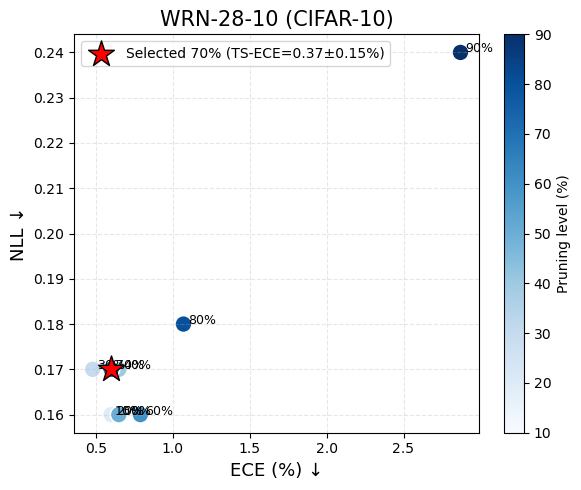

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths: CIFAR-10 selected-beta setting
# --------------------------------------------------

OURS_CSV = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE/HPO_beta_selection/"
    "cifar10_selected_beta_raw_metrics_paper.csv"
)

OURS_TS_CSV = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE/HPO_beta_selection/"
    "cifar10_selected_beta_temperature_scaled_metrics_paper.csv"
)

GD_CSV = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE/GD/"
    "cifar_raw_metrics_baseline_GD_0_90.csv"
)

GD_TS_CSV = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE/GD/"
    "cifar_ts_metrics_baseline_GD_0_90.csv"
)

OUT_DIR = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE/HPO_beta_selection"
)
os.makedirs(OUT_DIR, exist_ok=True)

OUT_SELECTED_CSV = os.path.join(
    OUT_DIR,
    "cifar10_pareto_selected_operating_point_with_ts_std.csv"
)

OUT_PARETO_CSV = os.path.join(
    OUT_DIR,
    "cifar10_pareto_front_points_with_ts_std.csv"
)

OUT_SELECTED_SUMMARY_CSV = os.path.join(
    OUT_DIR,
    "cifar10_pareto_selected_operating_point_summary_for_table.csv"
)

OUT_PLOT = os.path.join(
    OUT_DIR,
    "pareto_ece_nll_selected_beta_wrn_cifar10_with_ts_std.pdf"
)


# --------------------------------------------------
# Helpers
# --------------------------------------------------

def parse_mean_std(x):
    """
    Converts:
    '79.68 ± 0.25' -> (79.68, 0.25)
    '79.68'        -> (79.68, np.nan)
    '--'           -> (np.nan, np.nan)
    """
    x = str(x).strip()
    x = x.replace("%", "")
    x = x.replace("$", "")
    x = x.replace("\\pm", "±")
    x = x.replace("+/-", "±")

    if x in ["--", "nan", "NaN", "None", ""]:
        return np.nan, np.nan

    if "±" in x:
        mean, std = x.split("±", 1)
        return float(mean.strip()), float(std.strip())

    return float(x.strip()), np.nan


def parse_mean(x):
    return parse_mean_std(x)[0]


def parse_std(x):
    return parse_mean_std(x)[1]


def fmt_mean_std(mean, std, digits=2):
    if pd.isna(mean):
        return "--"
    if pd.isna(std):
        return f"{mean:.{digits}f}"
    return f"{mean:.{digits}f} ± {std:.{digits}f}"


def add_pruning_percent(df):
    df = df.copy()

    if "pruning_%" in df.columns:
        df["pruning_%"] = df["pruning_%"].apply(parse_mean).round(0).astype(int)

    elif "prune (%)" in df.columns:
        df["pruning_%"] = df["prune (%)"].apply(parse_mean).round(0).astype(int)

    elif "prune_ratio" in df.columns:
        if df["prune_ratio"].max() <= 1.0:
            df["pruning_%"] = (df["prune_ratio"] * 100).round(0).astype(int)
        else:
            df["pruning_%"] = df["prune_ratio"].round(0).astype(int)

    else:
        raise KeyError(
            "Could not find pruning column. Available columns:\n"
            + str(df.columns.tolist())
        )

    return df


def load_ours_raw_metrics(csv_path):
    df = pd.read_csv(csv_path)
    df = add_pruning_percent(df)

    required = ["acc (%)", "nll", "ece (%)"]
    missing = [c for c in required if c not in df.columns]
    if len(missing) > 0:
        raise KeyError(
            f"Missing columns in OUR raw CSV: {missing}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df["acc_mean"] = df["acc (%)"].apply(parse_mean)
    df["acc_std"]  = df["acc (%)"].apply(parse_std)

    df["nll_mean"] = df["nll"].apply(parse_mean)
    df["nll_std"]  = df["nll"].apply(parse_std)

    df["ece_mean"] = df["ece (%)"].apply(parse_mean)
    df["ece_std"]  = df["ece (%)"].apply(parse_std)

    if "beta" in df.columns:
        df["beta"] = df["beta"].astype(str)
    else:
        df["beta"] = "--"

    return df[[
        "pruning_%",
        "beta",
        "acc_mean",
        "acc_std",
        "nll_mean",
        "nll_std",
        "ece_mean",
        "ece_std",
    ]].copy()


def load_ours_ts_metrics(csv_path):
    df = pd.read_csv(csv_path)
    df = add_pruning_percent(df)

    required = ["raw_ece (%)", "raw_nll", "ts_ece (%)", "ts_nll", "temperature"]
    missing = [c for c in required if c not in df.columns]
    if len(missing) > 0:
        raise KeyError(
            f"Missing columns in OUR TS CSV: {missing}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df["ours_raw_ece_from_ts_mean"] = df["raw_ece (%)"].apply(parse_mean)
    df["ours_raw_ece_from_ts_std"]  = df["raw_ece (%)"].apply(parse_std)

    df["ours_raw_nll_from_ts_mean"] = df["raw_nll"].apply(parse_mean)
    df["ours_raw_nll_from_ts_std"]  = df["raw_nll"].apply(parse_std)

    df["ours_ts_ece_mean"] = df["ts_ece (%)"].apply(parse_mean)
    df["ours_ts_ece_std"]  = df["ts_ece (%)"].apply(parse_std)

    df["ours_ts_nll_mean"] = df["ts_nll"].apply(parse_mean)
    df["ours_ts_nll_std"]  = df["ts_nll"].apply(parse_std)

    df["ours_temperature_mean"] = df["temperature"].apply(parse_mean)
    df["ours_temperature_std"]  = df["temperature"].apply(parse_std)

    return df[[
        "pruning_%",
        "ours_raw_ece_from_ts_mean",
        "ours_raw_ece_from_ts_std",
        "ours_raw_nll_from_ts_mean",
        "ours_raw_nll_from_ts_std",
        "ours_ts_ece_mean",
        "ours_ts_ece_std",
        "ours_ts_nll_mean",
        "ours_ts_nll_std",
        "ours_temperature_mean",
        "ours_temperature_std",
    ]].copy()


def load_gd_raw_metrics(csv_path):
    df = pd.read_csv(csv_path)
    df = add_pruning_percent(df)

    required = ["acc (%)", "nll", "ece (%)"]
    missing = [c for c in required if c not in df.columns]
    if len(missing) > 0:
        raise KeyError(
            f"Missing columns in GD raw CSV: {missing}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df["acc_mean_gd"] = df["acc (%)"].apply(parse_mean)
    df["acc_std_gd"]  = df["acc (%)"].apply(parse_std)

    df["nll_mean_gd"] = df["nll"].apply(parse_mean)
    df["nll_std_gd"]  = df["nll"].apply(parse_std)

    df["ece_mean_gd"] = df["ece (%)"].apply(parse_mean)
    df["ece_std_gd"]  = df["ece (%)"].apply(parse_std)

    return df[[
        "pruning_%",
        "acc_mean_gd",
        "acc_std_gd",
        "nll_mean_gd",
        "nll_std_gd",
        "ece_mean_gd",
        "ece_std_gd",
    ]].copy()


def load_gd_ts_metrics(csv_path):
    df = pd.read_csv(csv_path)
    df = add_pruning_percent(df)

    required = ["raw_ece (%)", "raw_nll", "ts_ece (%)", "ts_nll", "temperature"]
    missing = [c for c in required if c not in df.columns]
    if len(missing) > 0:
        raise KeyError(
            f"Missing columns in GD TS CSV: {missing}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df["gd_raw_ece_from_ts_mean"] = df["raw_ece (%)"].apply(parse_mean)
    df["gd_raw_ece_from_ts_std"]  = df["raw_ece (%)"].apply(parse_std)

    df["gd_raw_nll_from_ts_mean"] = df["raw_nll"].apply(parse_mean)
    df["gd_raw_nll_from_ts_std"]  = df["raw_nll"].apply(parse_std)

    df["gd_ts_ece_mean"] = df["ts_ece (%)"].apply(parse_mean)
    df["gd_ts_ece_std"]  = df["ts_ece (%)"].apply(parse_std)

    df["gd_ts_nll_mean"] = df["ts_nll"].apply(parse_mean)
    df["gd_ts_nll_std"]  = df["ts_nll"].apply(parse_std)

    df["gd_temperature_mean"] = df["temperature"].apply(parse_mean)
    df["gd_temperature_std"]  = df["temperature"].apply(parse_std)

    return df[[
        "pruning_%",
        "gd_raw_ece_from_ts_mean",
        "gd_raw_ece_from_ts_std",
        "gd_raw_nll_from_ts_mean",
        "gd_raw_nll_from_ts_std",
        "gd_ts_ece_mean",
        "gd_ts_ece_std",
        "gd_ts_nll_mean",
        "gd_ts_nll_std",
        "gd_temperature_mean",
        "gd_temperature_std",
    ]].copy()


# --------------------------------------------------
# 1. Load OUR raw + TS selected-beta results
# --------------------------------------------------

df_ours_raw = load_ours_raw_metrics(OURS_CSV)
df_ours_ts = load_ours_ts_metrics(OURS_TS_CSV)

df_ours = df_ours_raw.merge(
    df_ours_ts,
    on="pruning_%",
    how="left"
)

print("OURS raw + TS:")
display(df_ours)


# --------------------------------------------------
# 2. Load GD raw + TS results
# --------------------------------------------------

df_gd_raw = load_gd_raw_metrics(GD_CSV)
df_gd_ts = load_gd_ts_metrics(GD_TS_CSV)

df_gd = df_gd_raw.merge(
    df_gd_ts,
    on="pruning_%",
    how="left"
)

print("GD raw + TS:")
display(df_gd)


# --------------------------------------------------
# 3. Merge ours + GD by pruning level
# --------------------------------------------------

df = df_ours.merge(
    df_gd,
    on="pruning_%",
    how="inner"
)

df = df.sort_values("pruning_%").reset_index(drop=True)

# Exclude unpruned baseline from operating-point selection
df = df[df["pruning_%"] > 0].copy()

print("Merged Ours + GD:")
display(df)


# --------------------------------------------------
# 4. Accuracy constraint relative to GD
# Rule: Ours must be within 1 percentage point of GD
# --------------------------------------------------

ACC_TOL_PCT = 1.0

df["acc_floor"] = df["acc_mean_gd"] - ACC_TOL_PCT
df_feasible = df[df["acc_mean"] >= df["acc_floor"]].copy()

print("Feasible pruning levels:", df_feasible["pruning_%"].tolist())

if len(df_feasible) == 0:
    raise ValueError(
        "No feasible pruning levels found. "
        "Try increasing ACC_TOL_PCT or check metric scaling."
    )


# --------------------------------------------------
# 5. Compute improvements/differences vs GD
# Lower is better for dECE and dNLL
# dECE < 0 means Ours has lower ECE than GD
# dNLL < 0 means Ours has lower NLL than GD
# --------------------------------------------------

df_feasible["dECE"] = df_feasible["ece_mean"] - df_feasible["ece_mean_gd"]
df_feasible["dNLL"] = df_feasible["nll_mean"] - df_feasible["nll_mean_gd"]

print("Feasible with raw + TS metrics and std:")
display(df_feasible[[
    "pruning_%",
    "beta",

    "acc_mean",
    "acc_std",
    "acc_mean_gd",
    "acc_std_gd",

    "ece_mean",
    "ece_std",
    "ece_mean_gd",
    "ece_std_gd",
    "dECE",

    "nll_mean",
    "nll_std",
    "nll_mean_gd",
    "nll_std_gd",
    "dNLL",

    "ours_ts_ece_mean",
    "ours_ts_ece_std",
    "gd_ts_ece_mean",
    "gd_ts_ece_std",

    "ours_ts_nll_mean",
    "ours_ts_nll_std",
    "gd_ts_nll_mean",
    "gd_ts_nll_std",

    "ours_temperature_mean",
    "gd_temperature_mean",
]])


# --------------------------------------------------
# 6. Pareto front on raw (dECE, dNLL)
# --------------------------------------------------

obj_cols = ["dECE", "dNLL"]

def is_dominated(i, data, cols):
    xi = data.loc[i, cols].to_numpy(dtype=float)

    for j in data.index:
        if j == i:
            continue

        xj = data.loc[j, cols].to_numpy(dtype=float)

        # j dominates i if j is no worse in all objectives
        # and strictly better in at least one objective
        if np.all(xj <= xi) and np.any(xj < xi):
            return True

    return False


pareto_idx = [
    i for i in df_feasible.index
    if not is_dominated(i, df_feasible, obj_cols)
]

df_pareto = df_feasible.loc[pareto_idx].sort_values("pruning_%").copy()

print("\nPareto pruning levels:", df_pareto["pruning_%"].tolist())

df_pareto.to_csv(OUT_PARETO_CSV, index=False)
print("Saved Pareto front ->", OUT_PARETO_CSV)

display(df_pareto[[
    "pruning_%",
    "beta",

    "acc_mean",
    "acc_std",

    "ece_mean",
    "ece_std",

    "nll_mean",
    "nll_std",

    "dECE",
    "dNLL",

    "ours_ts_ece_mean",
    "ours_ts_ece_std",
    "gd_ts_ece_mean",
    "gd_ts_ece_std",

    "ours_ts_nll_mean",
    "ours_ts_nll_std",
    "gd_ts_nll_mean",
    "gd_ts_nll_std",
]])


# --------------------------------------------------
# 7. Select one operating point
# Rule:
# 1. Best dECE
# 2. Then best dNLL
# 3. Then higher pruning
# --------------------------------------------------

df_selected = df_pareto.sort_values(
    ["dECE", "dNLL", "pruning_%"],
    ascending=[True, True, False]
).iloc[0].copy()

print("\nSelected operating point with TS metrics and std:")
display(pd.DataFrame([df_selected])[[
    "pruning_%",
    "beta",

    "acc_mean",
    "acc_std",
    "acc_mean_gd",
    "acc_std_gd",

    "ece_mean",
    "ece_std",
    "ece_mean_gd",
    "ece_std_gd",
    "dECE",

    "nll_mean",
    "nll_std",
    "nll_mean_gd",
    "nll_std_gd",
    "dNLL",

    "ours_ts_ece_mean",
    "ours_ts_ece_std",
    "gd_ts_ece_mean",
    "gd_ts_ece_std",

    "ours_ts_nll_mean",
    "ours_ts_nll_std",
    "gd_ts_nll_mean",
    "gd_ts_nll_std",

    "ours_temperature_mean",
    "gd_temperature_mean",
]])


# --------------------------------------------------
# 8. Save selected operating point
# --------------------------------------------------

pd.DataFrame([df_selected]).to_csv(OUT_SELECTED_CSV, index=False)
print("Saved selected operating point ->", OUT_SELECTED_CSV)


# --------------------------------------------------
# 8b. Save compact table row for paper
# --------------------------------------------------

selected_summary = pd.DataFrame([{
    "pruning_%": int(df_selected["pruning_%"]),
    "beta": df_selected["beta"],

    "ours_acc": fmt_mean_std(df_selected["acc_mean"], df_selected["acc_std"]),
    "gd_acc": fmt_mean_std(df_selected["acc_mean_gd"], df_selected["acc_std_gd"]),

    "ours_ece": fmt_mean_std(df_selected["ece_mean"], df_selected["ece_std"]),
    "gd_ece": fmt_mean_std(df_selected["ece_mean_gd"], df_selected["ece_std_gd"]),

    "ours_ts_ece": fmt_mean_std(df_selected["ours_ts_ece_mean"], df_selected["ours_ts_ece_std"]),
    "gd_ts_ece": fmt_mean_std(df_selected["gd_ts_ece_mean"], df_selected["gd_ts_ece_std"]),

    "ours_nll": fmt_mean_std(df_selected["nll_mean"], df_selected["nll_std"]),
    "gd_nll": fmt_mean_std(df_selected["nll_mean_gd"], df_selected["nll_std_gd"]),

    "ours_ts_nll": fmt_mean_std(df_selected["ours_ts_nll_mean"], df_selected["ours_ts_nll_std"]),
    "gd_ts_nll": fmt_mean_std(df_selected["gd_ts_nll_mean"], df_selected["gd_ts_nll_std"]),

    "ours_temperature": f"{df_selected['ours_temperature_mean']:.3f}",
    "gd_temperature": f"{df_selected['gd_temperature_mean']:.3f}",
}])

selected_summary.to_csv(OUT_SELECTED_SUMMARY_CSV, index=False)
print("Saved selected summary ->", OUT_SELECTED_SUMMARY_CSV)

display(selected_summary)


# --------------------------------------------------
# 9. Plot raw ECE vs raw NLL for feasible points
# Star includes Ours TS-ECE in label
# --------------------------------------------------

plot_df = df_feasible.sort_values("pruning_%").reset_index(drop=True)

plt.figure(figsize=(6, 5))

norm = plt.Normalize(plot_df["pruning_%"].min(), plot_df["pruning_%"].max())
cmap = plt.cm.Blues

sc = plt.scatter(
    plot_df["ece_mean"],
    plot_df["nll_mean"],
    c=plot_df["pruning_%"],
    cmap=cmap,
    norm=norm,
    s=150,
    edgecolor="white",
    linewidth=1.2
)

plt.scatter(
    df_selected["ece_mean"],
    df_selected["nll_mean"],
    marker="*",
    s=380,
    color="red",
    edgecolor="black",
    label=(
        f'Selected {int(df_selected["pruning_%"])}% '
        f'(TS-ECE={df_selected["ours_ts_ece_mean"]:.2f}'
        f'±{df_selected["ours_ts_ece_std"]:.2f}%)'
    ),
    zorder=5
)

for _, r in plot_df.iterrows():
    plt.text(
        r["ece_mean"] + 0.03,
        r["nll_mean"],
        f'{int(r["pruning_%"])}%',
        fontsize=9
    )

cbar = plt.colorbar(sc)
cbar.set_label("Pruning level (%)")

plt.title("WRN-28-10 (CIFAR-10)", fontsize=15)
plt.xlabel("ECE (%) ↓", fontsize=13)
plt.ylabel("NLL ↓", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_PLOT, dpi=300, bbox_inches="tight")
print("Saved plot ->", OUT_PLOT)

plt.show()

Saved merged CSV -> PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta_selection/accuracy_vs_effective_flops_ours_vs_gd_wrn_cifar10.csv


,pruning_%,ours_acc_mean,ours_acc_std,ours_flop_reduction_%,gd_acc_mean,gd_acc_std,gd_flop_reduction_%
0,0,93.90,0.24,0.000000,95.06,0.22,0.000000
1,10,94.71,0.21,19.000004,95.55,0.20,18.950759
2,20,94.44,0.24,35.999998,95.33,0.23,35.912283
3,30,94.46,0.22,51.000002,95.41,0.22,50.884572
4,40,94.54,0.24,63.999997,95.03,0.23,63.867626
5,50,94.73,0.22,75.000000,95.17,0.21,74.861446
6,60,94.59,0.24,84.000000,94.71,0.21,83.866031
7,70,94.37,0.22,90.999999,93.38,0.25,90.881381
8,80,94.17,0.23,96.000000,91.48,0.26,96.053222
9,90,92.22,0.27,99.000000,89.27,0.29,99.018002


Saved plot -> PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta_selection/accuracy_vs_effective_flops_ours_vs_gd_wrn_cifar10.pdf


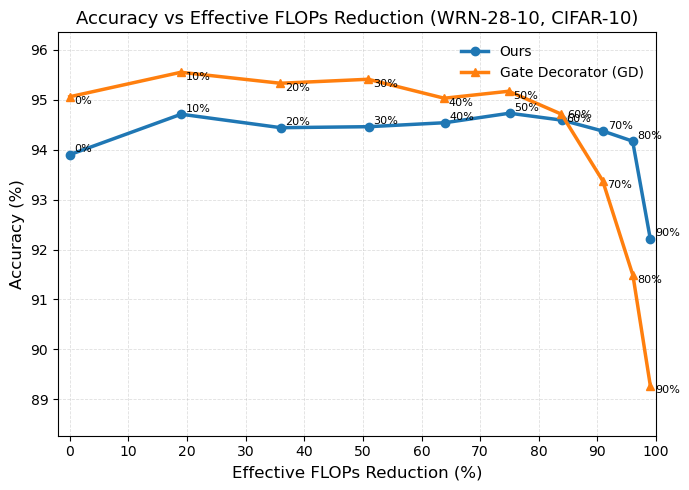

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths: CIFAR-10
# --------------------------------------------------

OURS_METRICS_CSV = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE/HPO_beta_selection/"
    "cifar10_selected_beta_raw_metrics_paper.csv"
)

GD_METRICS_CSV = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE/GD/"
    "cifar_raw_metrics_baseline_GD_0_90.csv"
)

# Update these if your FLOP CSV paths are different.
# If GD FLOP CSV does not exist, code will reuse Ours FLOP CSV.
OURS_FLOP_CSV =  "PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/SOFT_GATE/wrn28_10_cifar10_effective_flop_reduction_layerwise.csv"


GD_FLOP_CSV = "PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/GD/wrn28_10_cifar10_effective_flops_gd.csv"

OUT_DIR = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE/HPO_beta_selection"
)
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PLOT = os.path.join(
    OUT_DIR,
    "accuracy_vs_effective_flops_ours_vs_gd_wrn_cifar10.pdf"
)

OUT_MERGED_CSV = os.path.join(
    OUT_DIR,
    "accuracy_vs_effective_flops_ours_vs_gd_wrn_cifar10.csv"
)


# --------------------------------------------------
# Helpers
# --------------------------------------------------

def parse_mean_std(x):
    """
    Converts:
    '94.37 ± 0.22' -> (94.37, 0.22)
    '94.37'        -> (94.37, np.nan)
    """
    x = str(x).strip()
    x = x.replace("%", "")
    x = x.replace("$", "")
    x = x.replace("\\pm", "±")
    x = x.replace("+/-", "±")

    if x in ["--", "nan", "NaN", "None", ""]:
        return np.nan, np.nan

    if "±" in x:
        mean, std = x.split("±", 1)
        return float(mean.strip()), float(std.strip())

    return float(x.strip()), np.nan


def parse_mean(x):
    return parse_mean_std(x)[0]


def parse_std(x):
    return parse_mean_std(x)[1]


def add_pruning_percent(df):
    df = df.copy()

    if "pruning_%" in df.columns:
        df["pruning_%"] = df["pruning_%"].apply(parse_mean).round(0).astype(int)

    elif "prune (%)" in df.columns:
        df["pruning_%"] = df["prune (%)"].apply(parse_mean).round(0).astype(int)

    elif "Prune (%)" in df.columns:
        df["pruning_%"] = df["Prune (%)"].apply(parse_mean).round(0).astype(int)

    elif "prune_ratio" in df.columns:
        if df["prune_ratio"].max() <= 1.0:
            df["pruning_%"] = (df["prune_ratio"] * 100).round(0).astype(int)
        else:
            df["pruning_%"] = df["prune_ratio"].round(0).astype(int)

    else:
        raise KeyError(
            "Could not find pruning column. Available columns:\n"
            + str(df.columns.tolist())
        )

    return df


def find_acc_column(df):
    candidates = ["acc (%)", "Acc. (%)", "Acc (%)", "accuracy (%)", "Accuracy (%)"]
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        "Could not find accuracy column. Available columns:\n"
        + str(df.columns.tolist())
    )


def find_flop_reduction_column(df):
    candidates = [
        "effective_flop_reduction_%",
        "FLOP Reduction (%)",
        "FLOPs Red. (%)",
        "flop_reduction_%",
    ]

    for c in candidates:
        if c in df.columns:
            return c

    # fallback: search by name pattern
    matches = [
        c for c in df.columns
        if "flop" in c.lower()
        and "reduct" in c.lower()
    ]

    if len(matches) > 0:
        return matches[0]

    return None


def load_metrics(metrics_csv, method_name):
    df = pd.read_csv(metrics_csv)
    df = add_pruning_percent(df)

    acc_col = find_acc_column(df)

    df[f"{method_name}_acc_mean"] = df[acc_col].apply(parse_mean)
    df[f"{method_name}_acc_std"] = df[acc_col].apply(parse_std)

    keep_cols = [
        "pruning_%",
        f"{method_name}_acc_mean",
        f"{method_name}_acc_std",
    ]

    # If FLOP reduction is already in metrics file, keep it.
    flop_col = find_flop_reduction_column(df)
    if flop_col is not None:
        df[f"{method_name}_flop_reduction_%"] = df[flop_col].apply(parse_mean)
        keep_cols.append(f"{method_name}_flop_reduction_%")

    return df[keep_cols].copy()


def load_flops(flop_csv, method_name):
    df = pd.read_csv(flop_csv)
    df = add_pruning_percent(df)

    flop_col = find_flop_reduction_column(df)

    if flop_col is None:
        raise KeyError(
            f"Could not find FLOP reduction column in {flop_csv}.\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df[f"{method_name}_flop_reduction_%"] = df[flop_col].apply(parse_mean)

    return df[[
        "pruning_%",
        f"{method_name}_flop_reduction_%",
    ]].copy()


def attach_flops(metrics_df, flop_csv, method_name):
    """
    Adds FLOP reduction to metrics_df.
    If metrics_df already has it, keep it.
    Otherwise merge from flop_csv.
    """
    flop_col_name = f"{method_name}_flop_reduction_%"

    if flop_col_name in metrics_df.columns:
        return metrics_df

    if not os.path.exists(flop_csv):
        raise FileNotFoundError(
            f"FLOP CSV not found for {method_name}:\n{flop_csv}"
        )

    df_flop = load_flops(flop_csv, method_name)

    out = metrics_df.merge(
        df_flop,
        on="pruning_%",
        how="left"
    )

    return out


# --------------------------------------------------
# 1. Load Ours and GD metrics
# --------------------------------------------------

df_ours = load_metrics(OURS_METRICS_CSV, "ours")
df_gd = load_metrics(GD_METRICS_CSV, "gd")

# Attach FLOP reduction.
# If GD_FLOP_CSV does not exist, reuse OURS_FLOP_CSV as fallback.
df_ours = attach_flops(df_ours, OURS_FLOP_CSV, "ours")

if os.path.exists(GD_FLOP_CSV):
    df_gd = attach_flops(df_gd, GD_FLOP_CSV, "gd")
else:
    print("[WARN] GD_FLOP_CSV not found. Reusing OURS_FLOP_CSV for GD.")
    df_gd = attach_flops(df_gd, OURS_FLOP_CSV, "gd")


# --------------------------------------------------
# 2. Merge for inspection and save
# --------------------------------------------------

df_compare = df_ours.merge(
    df_gd,
    on="pruning_%",
    how="inner"
).sort_values("pruning_%").reset_index(drop=True)

df_compare.to_csv(OUT_MERGED_CSV, index=False)
print("Saved merged CSV ->", OUT_MERGED_CSV)

display(df_compare)


# --------------------------------------------------
# 3. Plot Accuracy vs Effective FLOP Reduction
# --------------------------------------------------

plt.figure(figsize=(7, 5))

# Ours
plt.plot(
    df_ours["ours_flop_reduction_%"],
    df_ours["ours_acc_mean"],
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="Ours",
)

# GD
plt.plot(
    df_gd["gd_flop_reduction_%"],
    df_gd["gd_acc_mean"],
    marker="^",
    linewidth=2.5,
    markersize=6,
    label="Gate Decorator (GD)",
)

# Annotate Ours pruning %
for _, row in df_ours.iterrows():
    plt.text(
        row["ours_flop_reduction_%"] + 0.8,
        row["ours_acc_mean"] + 0.05,
        f"{int(row['pruning_%'])}%",
        fontsize=8,
    )

# Annotate GD pruning %
for _, row in df_gd.iterrows():
    plt.text(
        row["gd_flop_reduction_%"] + 0.8,
        row["gd_acc_mean"] - 0.15,
        f"{int(row['pruning_%'])}%",
        fontsize=8,
    )

plt.xlabel("Effective FLOPs Reduction (%)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Accuracy vs Effective FLOPs Reduction (WRN-28-10, CIFAR-10)", fontsize=13)

plt.xlim(-2, 100)
plt.xticks(np.arange(0, 101, 10))

# CIFAR-10 accuracy range; adjust if needed
y_min = min(df_ours["ours_acc_mean"].min(), df_gd["gd_acc_mean"].min()) - 1.0
y_max = max(df_ours["ours_acc_mean"].max(), df_gd["gd_acc_mean"].max()) + 0.8
plt.ylim(y_min, y_max)

plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(OUT_PLOT, dpi=300, bbox_inches="tight")
print("Saved plot ->", OUT_PLOT)

plt.show()

Saved merged CSV -> PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta_selection/ece_vs_effective_flops_ours_vs_gd_wrn_cifar10.csv


,pruning_%,ours_ece_mean,ours_ece_std,ours_flop_reduction_%,gd_ece_mean,gd_ece_std,gd_flop_reduction_%
0,0,1.90,0.20,0.000000,2.81,0.19,0.000000
1,10,0.59,0.15,19.000004,2.55,0.18,18.950759
2,20,0.60,0.15,35.999998,2.75,0.20,35.912283
3,30,0.48,0.14,51.000002,2.65,0.18,50.884572
4,40,0.65,0.16,63.999997,2.98,0.20,63.867626
5,50,0.65,0.15,75.000000,2.74,0.18,74.861446
6,60,0.79,0.14,84.000000,3.05,0.19,83.866031
7,70,0.60,0.15,90.999999,3.43,0.22,90.881381
8,80,1.07,0.16,96.000000,3.89,0.23,96.053222
9,90,2.87,0.23,99.000000,3.12,0.23,99.018002


Saved plot -> PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta_selection/ece_vs_effective_flops_ours_vs_gd_wrn_cifar10.pdf


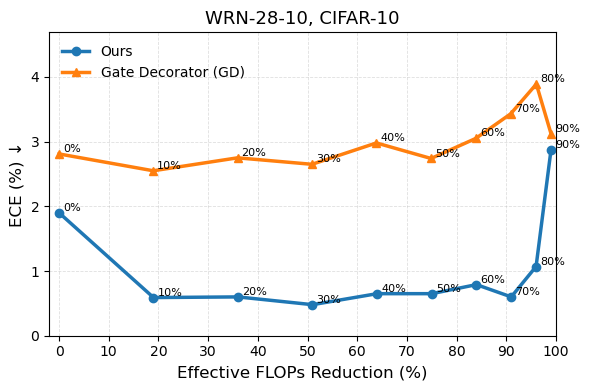

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths: CIFAR-10
# --------------------------------------------------


OUT_PLOT = os.path.join(
    OUT_DIR,
    "ece_vs_effective_flops_ours_vs_gd_wrn_cifar10.pdf"
)

OUT_MERGED_CSV = os.path.join(
    OUT_DIR,
    "ece_vs_effective_flops_ours_vs_gd_wrn_cifar10.csv"
)


# --------------------------------------------------
# Helpers
# --------------------------------------------------

def parse_mean_std(x):
    """
    Converts:
    '0.60 ± 0.15' -> (0.60, 0.15)
    '0.60'        -> (0.60, np.nan)
    """
    x = str(x).strip()
    x = x.replace("%", "")
    x = x.replace("$", "")
    x = x.replace("\\pm", "±")
    x = x.replace("+/-", "±")

    if x in ["--", "nan", "NaN", "None", ""]:
        return np.nan, np.nan

    if "±" in x:
        mean, std = x.split("±", 1)
        return float(mean.strip()), float(std.strip())

    return float(x.strip()), np.nan


def parse_mean(x):
    return parse_mean_std(x)[0]


def parse_std(x):
    return parse_mean_std(x)[1]


def add_pruning_percent(df):
    df = df.copy()

    if "pruning_%" in df.columns:
        df["pruning_%"] = df["pruning_%"].apply(parse_mean).round(0).astype(int)

    elif "prune (%)" in df.columns:
        df["pruning_%"] = df["prune (%)"].apply(parse_mean).round(0).astype(int)

    elif "Prune (%)" in df.columns:
        df["pruning_%"] = df["Prune (%)"].apply(parse_mean).round(0).astype(int)

    elif "prune_ratio" in df.columns:
        if df["prune_ratio"].max() <= 1.0:
            df["pruning_%"] = (df["prune_ratio"] * 100).round(0).astype(int)
        else:
            df["pruning_%"] = df["prune_ratio"].round(0).astype(int)

    else:
        raise KeyError(
            "Could not find pruning column. Available columns:\n"
            + str(df.columns.tolist())
        )

    return df


def find_ece_column(df):
    candidates = ["ece (%)", "ECE (%)", "ece", "ECE"]
    for c in candidates:
        if c in df.columns:
            return c

    matches = [c for c in df.columns if "ece" in c.lower() and "ts" not in c.lower()]
    if len(matches) > 0:
        return matches[0]

    raise KeyError(
        "Could not find ECE column. Available columns:\n"
        + str(df.columns.tolist())
    )


def find_flop_reduction_column(df):
    candidates = [
        "effective_flop_reduction_%",
        "FLOP Reduction (%)",
        "FLOPs Red. (%)",
        "flop_reduction_%",
    ]

    for c in candidates:
        if c in df.columns:
            return c

    matches = [
        c for c in df.columns
        if "flop" in c.lower()
        and "reduct" in c.lower()
    ]

    if len(matches) > 0:
        return matches[0]

    return None


def load_metrics(metrics_csv, method_name):
    df = pd.read_csv(metrics_csv)
    df = add_pruning_percent(df)

    ece_col = find_ece_column(df)

    df[f"{method_name}_ece_mean"] = df[ece_col].apply(parse_mean)
    df[f"{method_name}_ece_std"] = df[ece_col].apply(parse_std)

    keep_cols = [
        "pruning_%",
        f"{method_name}_ece_mean",
        f"{method_name}_ece_std",
    ]

    flop_col = find_flop_reduction_column(df)
    if flop_col is not None:
        df[f"{method_name}_flop_reduction_%"] = df[flop_col].apply(parse_mean)
        keep_cols.append(f"{method_name}_flop_reduction_%")

    return df[keep_cols].copy()


def load_flops(flop_csv, method_name):
    df = pd.read_csv(flop_csv)
    df = add_pruning_percent(df)

    flop_col = find_flop_reduction_column(df)

    if flop_col is None:
        raise KeyError(
            f"Could not find FLOP reduction column in {flop_csv}.\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df[f"{method_name}_flop_reduction_%"] = df[flop_col].apply(parse_mean)

    return df[[
        "pruning_%",
        f"{method_name}_flop_reduction_%",
    ]].copy()


def attach_flops(metrics_df, flop_csv, method_name):
    flop_col_name = f"{method_name}_flop_reduction_%"

    if flop_col_name in metrics_df.columns:
        return metrics_df

    if not os.path.exists(flop_csv):
        raise FileNotFoundError(
            f"FLOP CSV not found for {method_name}:\n{flop_csv}"
        )

    df_flop = load_flops(flop_csv, method_name)

    out = metrics_df.merge(
        df_flop,
        on="pruning_%",
        how="left"
    )

    return out


# --------------------------------------------------
# 1. Load Ours and GD metrics
# --------------------------------------------------

df_ours = load_metrics(OURS_METRICS_CSV, "ours")
df_gd = load_metrics(GD_METRICS_CSV, "gd")

df_ours = attach_flops(df_ours, OURS_FLOP_CSV, "ours")

if os.path.exists(GD_FLOP_CSV):
    df_gd = attach_flops(df_gd, GD_FLOP_CSV, "gd")
else:
    print("[WARN] GD_FLOP_CSV not found. Reusing OURS_FLOP_CSV for GD.")
    df_gd = attach_flops(df_gd, OURS_FLOP_CSV, "gd")


# --------------------------------------------------
# 2. Merge for inspection and save
# --------------------------------------------------

df_compare = df_ours.merge(
    df_gd,
    on="pruning_%",
    how="inner"
).sort_values("pruning_%").reset_index(drop=True)

df_compare.to_csv(OUT_MERGED_CSV, index=False)
print("Saved merged CSV ->", OUT_MERGED_CSV)

display(df_compare)


# --------------------------------------------------
# 3. Plot ECE vs Effective FLOP Reduction
# --------------------------------------------------

plt.figure(figsize=(6, 4))

# Ours
plt.plot(
    df_ours["ours_flop_reduction_%"],
    df_ours["ours_ece_mean"],
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="Ours",
)

# GD
plt.plot(
    df_gd["gd_flop_reduction_%"],
    df_gd["gd_ece_mean"],
    marker="^",
    linewidth=2.5,
    markersize=6,
    label="Gate Decorator (GD)",
)

# Annotate Ours pruning %
for _, row in df_ours.iterrows():
    plt.text(
        row["ours_flop_reduction_%"] + 0.8,
        row["ours_ece_mean"] + 0.03,
        f"{int(row['pruning_%'])}%",
        fontsize=8,
    )

# Annotate GD pruning %
for _, row in df_gd.iterrows():
    plt.text(
        row["gd_flop_reduction_%"] + 0.8,
        row["gd_ece_mean"] + 0.03,
        f"{int(row['pruning_%'])}%",
        fontsize=8,
    )

plt.xlabel("Effective FLOPs Reduction (%)", fontsize=12)
plt.ylabel("ECE (%) ↓", fontsize=12)
plt.title("WRN-28-10, CIFAR-10", fontsize=13)

plt.xlim(-2, 100)
plt.xticks(np.arange(0, 101, 10))

y_min = 0
y_max = max(df_ours["ours_ece_mean"].max(), df_gd["gd_ece_mean"].max()) + 0.8
plt.ylim(y_min, y_max)

plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(OUT_PLOT, dpi=300, bbox_inches="tight")
print("Saved plot ->", OUT_PLOT)

plt.show()

Saved merged CSV -> PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta_selection/acc_ece_vs_effective_flops_ours_vs_gd_wrn_cifar10.csv


,pruning_%,ours_acc_mean,ours_acc_std,ours_ece_mean,ours_ece_std,ours_flop_reduction_%,gd_acc_mean,gd_acc_std,gd_ece_mean,gd_ece_std,gd_flop_reduction_%
0,0,93.90,0.24,1.90,0.20,0.000000,95.06,0.22,2.81,0.19,0.000000
1,10,94.71,0.21,0.59,0.15,19.000004,95.55,0.20,2.55,0.18,18.950759
2,20,94.44,0.24,0.60,0.15,35.999998,95.33,0.23,2.75,0.20,35.912283
3,30,94.46,0.22,0.48,0.14,51.000002,95.41,0.22,2.65,0.18,50.884572
4,40,94.54,0.24,0.65,0.16,63.999997,95.03,0.23,2.98,0.20,63.867626
5,50,94.73,0.22,0.65,0.15,75.000000,95.17,0.21,2.74,0.18,74.861446
6,60,94.59,0.24,0.79,0.14,84.000000,94.71,0.21,3.05,0.19,83.866031
7,70,94.37,0.22,0.60,0.15,90.999999,93.38,0.25,3.43,0.22,90.881381
8,80,94.17,0.23,1.07,0.16,96.000000,91.48,0.26,3.89,0.23,96.053222
9,90,92.22,0.27,2.87,0.23,99.000000,89.27,0.29,3.12,0.23,99.018002


Saved combined plot -> PRUNING/WRN28-10_CIFAR10/FOCAL_SBECE_PRUNE/HPO_beta_selection/acc_ece_vs_effective_flops_ours_vs_gd_wrn_cifar10_1row2col.pdf


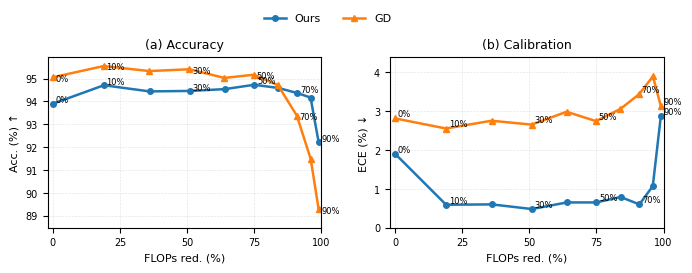

In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths: CIFAR-10
# --------------------------------------------------

OURS_METRICS_CSV = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE/HPO_beta_selection/"
    "cifar10_selected_beta_raw_metrics_paper.csv"
)

GD_METRICS_CSV = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE/GD/"
    "cifar_raw_metrics_baseline_GD_0_90.csv"
)

OURS_FLOP_CSV = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE/SOFT_GATE/"
    "wrn28_10_cifar10_effective_flop_reduction_layerwise.csv"
)

GD_FLOP_CSV = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE/GD/"
    "wrn28_10_cifar10_effective_flops_gd.csv"
)

OUT_DIR = (
    "PRUNING/WRN28-10_CIFAR10/"
    "FOCAL_SBECE_PRUNE/HPO_beta_selection"
)
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PLOT = os.path.join(
    OUT_DIR,
    "acc_ece_vs_effective_flops_ours_vs_gd_wrn_cifar10_1row2col.pdf"
)

OUT_MERGED_CSV = os.path.join(
    OUT_DIR,
    "acc_ece_vs_effective_flops_ours_vs_gd_wrn_cifar10.csv"
)


# --------------------------------------------------
# Helpers
# --------------------------------------------------

def parse_mean_std(x):
    """
    Converts:
    '94.37 ± 0.22' -> (94.37, 0.22)
    '94.37'        -> (94.37, np.nan)
    """
    x = str(x).strip()
    x = x.replace("%", "")
    x = x.replace("$", "")
    x = x.replace("\\pm", "±")
    x = x.replace("+/-", "±")

    if x in ["--", "nan", "NaN", "None", ""]:
        return np.nan, np.nan

    if "±" in x:
        mean, std = x.split("±", 1)
        return float(mean.strip()), float(std.strip())

    return float(x.strip()), np.nan


def parse_mean(x):
    return parse_mean_std(x)[0]


def parse_std(x):
    return parse_mean_std(x)[1]


def add_pruning_percent(df):
    df = df.copy()

    if "pruning_%" in df.columns:
        df["pruning_%"] = df["pruning_%"].apply(parse_mean).round(0).astype(int)

    elif "prune (%)" in df.columns:
        df["pruning_%"] = df["prune (%)"].apply(parse_mean).round(0).astype(int)

    elif "Prune (%)" in df.columns:
        df["pruning_%"] = df["Prune (%)"].apply(parse_mean).round(0).astype(int)

    elif "prune_ratio" in df.columns:
        if df["prune_ratio"].max() <= 1.0:
            df["pruning_%"] = (df["prune_ratio"] * 100).round(0).astype(int)
        else:
            df["pruning_%"] = df["prune_ratio"].round(0).astype(int)

    else:
        raise KeyError(
            "Could not find pruning column. Available columns:\n"
            + str(df.columns.tolist())
        )

    return df


def find_acc_column(df):
    candidates = ["acc (%)", "Acc. (%)", "Acc (%)", "accuracy (%)", "Accuracy (%)"]
    for c in candidates:
        if c in df.columns:
            return c

    raise KeyError(
        "Could not find accuracy column. Available columns:\n"
        + str(df.columns.tolist())
    )


def find_ece_column(df):
    candidates = ["ece (%)", "ECE (%)", "ece", "ECE"]
    for c in candidates:
        if c in df.columns:
            return c

    matches = [
        c for c in df.columns
        if "ece" in c.lower() and "ts" not in c.lower()
    ]

    if len(matches) > 0:
        return matches[0]

    raise KeyError(
        "Could not find ECE column. Available columns:\n"
        + str(df.columns.tolist())
    )


def find_flop_reduction_column(df):
    candidates = [
        "effective_flop_reduction_%",
        "FLOP Reduction (%)",
        "FLOPs Red. (%)",
        "flop_reduction_%",
    ]

    for c in candidates:
        if c in df.columns:
            return c

    matches = [
        c for c in df.columns
        if "flop" in c.lower()
        and "reduct" in c.lower()
    ]

    if len(matches) > 0:
        return matches[0]

    return None


def load_metrics(metrics_csv, method_name):
    df = pd.read_csv(metrics_csv)
    df = add_pruning_percent(df)

    acc_col = find_acc_column(df)
    ece_col = find_ece_column(df)

    df[f"{method_name}_acc_mean"] = df[acc_col].apply(parse_mean)
    df[f"{method_name}_acc_std"] = df[acc_col].apply(parse_std)

    df[f"{method_name}_ece_mean"] = df[ece_col].apply(parse_mean)
    df[f"{method_name}_ece_std"] = df[ece_col].apply(parse_std)

    keep_cols = [
        "pruning_%",
        f"{method_name}_acc_mean",
        f"{method_name}_acc_std",
        f"{method_name}_ece_mean",
        f"{method_name}_ece_std",
    ]

    flop_col = find_flop_reduction_column(df)
    if flop_col is not None:
        df[f"{method_name}_flop_reduction_%"] = df[flop_col].apply(parse_mean)
        keep_cols.append(f"{method_name}_flop_reduction_%")

    return df[keep_cols].copy()


def load_flops(flop_csv, method_name):
    df = pd.read_csv(flop_csv)
    df = add_pruning_percent(df)

    flop_col = find_flop_reduction_column(df)

    if flop_col is None:
        raise KeyError(
            f"Could not find FLOP reduction column in {flop_csv}.\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df[f"{method_name}_flop_reduction_%"] = df[flop_col].apply(parse_mean)

    return df[[
        "pruning_%",
        f"{method_name}_flop_reduction_%",
    ]].copy()


def attach_flops(metrics_df, flop_csv, method_name):
    flop_col_name = f"{method_name}_flop_reduction_%"

    if flop_col_name in metrics_df.columns:
        return metrics_df

    if not os.path.exists(flop_csv):
        raise FileNotFoundError(
            f"FLOP CSV not found for {method_name}:\n{flop_csv}"
        )

    df_flop = load_flops(flop_csv, method_name)

    out = metrics_df.merge(
        df_flop,
        on="pruning_%",
        how="left"
    )

    return out


# --------------------------------------------------
# 1. Load Ours and GD metrics
# --------------------------------------------------

df_ours = load_metrics(OURS_METRICS_CSV, "ours")
df_gd = load_metrics(GD_METRICS_CSV, "gd")

df_ours = attach_flops(df_ours, OURS_FLOP_CSV, "ours")

if os.path.exists(GD_FLOP_CSV):
    df_gd = attach_flops(df_gd, GD_FLOP_CSV, "gd")
else:
    print("[WARN] GD_FLOP_CSV not found. Reusing OURS_FLOP_CSV for GD.")
    df_gd = attach_flops(df_gd, OURS_FLOP_CSV, "gd")


# --------------------------------------------------
# 2. Merge and save for inspection
# --------------------------------------------------

df_compare = df_ours.merge(
    df_gd,
    on="pruning_%",
    how="inner"
).sort_values("pruning_%").reset_index(drop=True)

df_compare.to_csv(OUT_MERGED_CSV, index=False)
print("Saved merged CSV ->", OUT_MERGED_CSV)

display(df_compare)


# --------------------------------------------------
# 3. Plot: 1 row x 2 columns (cleaner version)
# --------------------------------------------------

# Slightly taller than before
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8), sharex=False)

ax_acc, ax_ece = axes

# label only a few important pruning levels
LABEL_PRUNES = [0, 10,30, 50, 70, 90]

# ----------------------------
# Left: Accuracy vs FLOPs
# ----------------------------

ax_acc.plot(
    df_ours["ours_flop_reduction_%"],
    df_ours["ours_acc_mean"],
    marker="o",
    linewidth=1.8,
    markersize=4.0,
    label="Ours",
)

ax_acc.plot(
    df_gd["gd_flop_reduction_%"],
    df_gd["gd_acc_mean"],
    marker="^",
    linewidth=1.8,
    markersize=4.0,
    label="GD",
)

for _, row in df_ours.iterrows():
    if int(row["pruning_%"]) in LABEL_PRUNES:
        ax_acc.text(
            row["ours_flop_reduction_%"] + 1.0,
            row["ours_acc_mean"] + 0.05,
            f"{int(row['pruning_%'])}%",
            fontsize=6,
        )

for _, row in df_gd.iterrows():
    if int(row["pruning_%"]) in LABEL_PRUNES:
        ax_acc.text(
            row["gd_flop_reduction_%"] + 1.0,
            row["gd_acc_mean"] - 0.16,
            f"{int(row['pruning_%'])}%",
            fontsize=6,
        )

ax_acc.set_title("(a) Accuracy", fontsize=9)
ax_acc.set_xlabel("FLOPs red. (%)", fontsize=8)
ax_acc.set_ylabel("Acc. (%) ↑", fontsize=8)
ax_acc.set_xlim(-2, 100)
ax_acc.set_xticks([0, 25, 50, 75, 100])

acc_y_min = min(df_ours["ours_acc_mean"].min(), df_gd["gd_acc_mean"].min()) - 0.8
acc_y_max = max(df_ours["ours_acc_mean"].max(), df_gd["gd_acc_mean"].max()) + 0.4
ax_acc.set_ylim(acc_y_min, acc_y_max)

ax_acc.grid(True, linestyle="--", linewidth=0.45, alpha=0.35)
ax_acc.tick_params(axis="both", labelsize=7)


# ----------------------------
# Right: ECE vs FLOPs
# ----------------------------

ax_ece.plot(
    df_ours["ours_flop_reduction_%"],
    df_ours["ours_ece_mean"],
    marker="o",
    linewidth=1.8,
    markersize=4.0,
    label="Ours",
)

ax_ece.plot(
    df_gd["gd_flop_reduction_%"],
    df_gd["gd_ece_mean"],
    marker="^",
    linewidth=1.8,
    markersize=4.0,
    label="GD",
)

for _, row in df_ours.iterrows():
    if int(row["pruning_%"]) in LABEL_PRUNES:
        ax_ece.text(
            row["ours_flop_reduction_%"] + 1.0,
            row["ours_ece_mean"] + 0.05,
            f"{int(row['pruning_%'])}%",
            fontsize=6,
        )

for _, row in df_gd.iterrows():
    if int(row["pruning_%"]) in LABEL_PRUNES:
        ax_ece.text(
            row["gd_flop_reduction_%"] + 1.0,
            row["gd_ece_mean"] + 0.05,
            f"{int(row['pruning_%'])}%",
            fontsize=6,
        )

ax_ece.set_title("(b) Calibration", fontsize=9)
ax_ece.set_xlabel("FLOPs red. (%)", fontsize=8)
ax_ece.set_ylabel("ECE (%) ↓", fontsize=8)
ax_ece.set_xlim(-2, 100)
ax_ece.set_xticks([0, 25, 50, 75, 100])

ece_y_min = 0
ece_y_max = max(df_ours["ours_ece_mean"].max(), df_gd["gd_ece_mean"].max()) + 0.5
ax_ece.set_ylim(ece_y_min, ece_y_max)

ax_ece.grid(True, linestyle="--", linewidth=0.45, alpha=0.35)
ax_ece.tick_params(axis="both", labelsize=7)


# ----------------------------
# Shared legend
# ----------------------------

handles, labels = ax_acc.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=8,
    bbox_to_anchor=(0.5, 1.02),
)

plt.subplots_adjust(top=0.83, wspace=0.25, bottom=0.22, left=0.10, right=0.98)

plt.savefig(OUT_PLOT, dpi=300, bbox_inches="tight")
print("Saved combined plot ->", OUT_PLOT)

plt.show()